# UBS and JPMorgan earnings calls, 2022 to 2025: topics and themes around the two mergers

Willian Angelo · Team 10 · Bank of England employer project (CAM_DS_401) · release `2026-09-30`

The topic track for Assignment 3. The extended release covers both banks from 2022-Q1 to 2025-Q4, so the conversation can be read a year before the 2023 deals and two years after them. The analyst and management Q&A is modelled two ways: BERTopic finds the topics without being told what to look for, and the Sentence-BERT theme tagger fine-tuned in `angelo.ipynb` assigns each sentence to one of seven fixed themes. The results are then set against the quarters the team's sentiment models flagged. `angelo.ipynb` stays as the Assignment 2 record on the 23 September release.

Outputs print transcript text. **Clear all outputs before every commit** (public repository).

## Environment

Team setup cell with `NAME = "angelo"`, then `EXPORT = "2026-09-30"`. The cells below expect `ROOT`, `DATA`, `EXPORT` and `loading`.

In [1]:
# 0.0 local Windows only, run before the setup cell: pandas loads pyarrow, whose bundled msvcp140.dll
# is older than the one torch needs, and torch then fails with WinError 1114. Harmless in Colab.
import torch

Loads PyTorch before anything else. On Windows, loading pandas first stops PyTorch from starting, so this line only keeps the notebook running; it does no analysis.

In [2]:
# project setup - run first, do not edit except NAME
NAME = "angelo"  # <<< your name

import sys, subprocess, pathlib
IN_COLAB = "google.colab" in sys.modules
REPO = "boe-financial-analysis"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    if not pathlib.Path(f"/content/{REPO}").exists():
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/maybebool/{REPO}.git",
                        f"/content/{REPO}"], check=True)
    ROOT = pathlib.Path(f"/content/{REPO}")
    DATA = pathlib.Path("/content/drive/MyDrive/boe-data")
else:
    ROOT = pathlib.Path.cwd()
    while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    DATA = ROOT / "data"

sys.path.insert(0, str(ROOT))
subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin"], check=False)
subprocess.run(["git", "-C", str(ROOT), "merge", "-q", "origin/main", "-m", "sync"],
               check=False)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r",
                str(ROOT / "requirements.txt")], check=True)

from notebooks.env_cell import verify, check_python
check_python()
try:
    verify(ROOT)
except RuntimeError as e:
    print(e)
    print("\n Runtime -> Restart session, then run this cell again.")
    raise

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src import loading

print(f"ok  python {sys.version.split()[0]}  pandas {pd.__version__}  data {DATA}")

ok  python 3.13.15  pandas 2.2.3  data C:\local_CAM\Emp_Proj\boe-financial-analysis\data


Standard project set-up: finds the project folder, updates the code from the team's shared branch, installs the pinned library versions and checks them. The output confirms Python 3.13 and pandas 2.2.3, so the results can be reproduced on another machine.

In [3]:
EXPORT = "2026-09-30"  # pin the export this notebook was written against
print("exports:", loading.exports(DATA))
print("files:  ", loading.files(DATA, EXPORT))

sentences_df = loading.load(DATA, "structured_sentences.csv", EXPORT)

exports: ['2026-09-13', '2026-09-23', '2026-09-30', 'Never ever upload or change something in the folder above']
files:   ['exchange_texts.csv', 'qa_exchanges_utterance_level.csv', 'structured_sentences.csv', 'structured_utterances.csv']
loaded structured_sentences.csv  19092 rows


Fixes the analysis to the 30 September release, which extends the data to 2022 to 2025, and loads its sentence file: 19,092 sentences from 33 calls. The release has four files: sentences, speaker turns, Q&A exchanges and the exchange questions.

In [4]:
sentences_df

,bank,quarter,call_type,call_date,position_in_call,section,speaker_role,speaker_name,speaker_institution,sentence_id,sentence_number,sentence,utterance_id,sentence_raw,is_filler_sentence
0,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38068,1,"Good morning, ladies and gentlemen.",0,"Good morning, ladies and gentlemen.",True
1,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38069,2,Welcome to JPMorgan Chase's First Quarter 2022...,0,Welcome to JPMorgan Chase's First Quarter 2022...,False
2,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38070,3,This call is being recorded.,0,This call is being recorded.,False
3,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38071,4,Your line will be muted for the duration of th...,0,Your line will be muted for the duration of th...,False
4,JPM,2022-Q1,earnings,2022-04-13,1,prepared,operator,Operator,NaN,38072,5,We will now go live to the presentation.,0,We will now go live to the presentation.,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19087,UBS,2025-Q4,earnings,2026-02-04,42,qa,management,Todd Tuckner,NaN,38063,11,"But look, we always believe that the IB will b...",41,"But look, we always believe that the IB will b...",False
19088,UBS,2025-Q4,earnings,2026-02-04,43,qa,analyst,Benjamin Goy,Deutsche Bank,38064,1,Thank you.,42,Thank you.,True
19089,UBS,2025-Q4,earnings,2026-02-04,44,qa,ir,Sarah Mackey,NaN,38065,1,I think there are no further questions.,43,I think there are no further questions.,False
19090,UBS,2025-Q4,earnings,2026-02-04,44,qa,ir,Sarah Mackey,NaN,38066,2,We just thank everyone for dialing in and we l...,43,We just thank everyone for dialing in and we l...,False


A first look at the data: one row per sentence, with the bank, quarter, call type, section (prepared remarks or Q&A), speaker, the sentence text and a flag for filler sentences such as "Thank you.".

## Data import and cleaning

In [5]:
# 1.0 settings shared by every section
try:
    import torch
except OSError as e:
    raise OSError("torch failed to load because pandas loaded first: restart the kernel "
                  "and run the 0.0 cell before the setup cell") from e
import gc, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for name in ("ROOT", "DATA", "EXPORT", "loading"):
    if name not in globals():
        raise NameError(f"run the Environment cell first: {name} is not defined")
if EXPORT not in loading.exports(DATA):
    raise FileNotFoundError(f"release {EXPORT} is not in {DATA / 'results'}")

SEED = 42
OUT = ROOT / "notebooks" / "angelo" / "outputs" / EXPORT      # outputs/ is kept out of git by .git/info/exclude
A2_OUT = ROOT / "notebooks" / "angelo" / "outputs" / "2026-09-23"   # angelo.ipynb: the fine-tuned theme model
if DATA in OUT.parents:
    raise RuntimeError(f"never write inside {DATA}: it holds the read-only release")
OUT.mkdir(parents=True, exist_ok=True)
FIG = OUT / "figures"                                           # charts saved for the slides
FIG.mkdir(exist_ok=True)

BANKS = ["UBS", "JPM"]
ROLES = ["analyst", "management"]
YEARS = [2022, 2023, 2024, 2025]
QUARTERS = [f"{y}-Q{q}" for y in YEARS for q in (1, 2, 3, 4)]
CALL_ID = ["bank", "quarter", "call_type"]
TURN = CALL_ID + ["position_in_call"]
KEY = TURN + ["sentence_number"]               # joins results across releases and across the team's tracks

# windows around the 2023 deals, the same for both banks (proposed): the year before, the two deal quarters
# (UBS announced Credit Suisse in March and closed in June; JPMorgan bought First Republic on 1 May),
# the first year after, and the six later quarters
WINDOWS = {"before": QUARTERS[0:4], "deal": QUARTERS[4:6], "after": QUARTERS[6:10], "later": QUARTERS[10:16]}
WINDOW_OF = {q: w for w, qs in WINDOWS.items() for q in qs}
WINDOW_NAMES = list(WINDOWS)

# breaks marked on every time chart
BREAKS = {"UBS": ("2023-Q2", "Credit Suisse consolidated"),
          "JPM": ("2024-Q2", "Visa gain, CFO-only call")}

# the one event call: JPMorgan's First Republic deal call (1 May 2023), filed under 2023-Q2 next to that
# quarter's earnings call. It stays in the corpus; results per quarter pool it with the earnings call.
EVENT = ("JPM", "2023-Q2", "event")
EVENT_NOTE = "Diamond: JPM's First Republic deal call on its own (1 May 2023)"

# chart style: one fixed colour per bank, recessive grid and axes
BANK_COLOR = {"UBS": "#2a78d6", "JPM": "#eb6834"}
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "lines.linewidth": 2,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})
pd.set_option("display.max_colwidth", 120)
print(f"release {EXPORT}   outputs {OUT}")

release 2026-09-30   outputs C:\local_CAM\Emp_Proj\boe-financial-analysis\notebooks\angelo\outputs\2026-09-30


Sets the constants used throughout: the two banks, the 16 quarters from 2022 to 2025, a random seed for repeatable results and the output folder. It also defines four windows around the 2023 acquisitions (UBS bought Credit Suisse, JPMorgan bought First Republic): the year before, the two deal quarters, the first year after and the six later quarters. Two quarters with known breaks in the reported figures and JPMorgan's deal call are marked so the charts can show them.

In [6]:
# 1.1 load the pinned release: sentences, speaker turns (utterances) and the Q&A exchanges
sent_raw = loading.load(DATA, "structured_sentences.csv", EXPORT)
utt_raw = loading.load(DATA, "structured_utterances.csv", EXPORT)
exch_raw = loading.load(DATA, "qa_exchanges_utterance_level.csv", EXPORT)

loaded structured_sentences.csv  19092 rows
loaded structured_utterances.csv  2570 rows
loaded qa_exchanges_utterance_level.csv  2473 rows


Loads the three tables used: 19,092 sentences, 2,570 speaker turns and 2,473 rows that link each Q&A turn to its exchange.

In [7]:
# 1.2 data tests: stop if the release is not what its guide describes
FUSED = re.compile(r"\b(?:do|did|does|would|wo|have|are|should|ca|is|was|has|had|were|could)not\b", re.I)
linked = sent_raw.merge(utt_raw[TURN], on=TURN, how="left", indicator=True)
exch_linked = exch_raw.merge(utt_raw[TURN], on=TURN, how="left", indicator=True)
event_calls = set(sent_raw.loc[sent_raw["call_type"] == "event", ["bank", "quarter"]]
                  .itertuples(index=False, name=None))
earnings = sent_raw[sent_raw["call_type"] == "earnings"].groupby("bank")["quarter"].agg(lambda s: sorted(s.unique()))

checks = {
    "19,092 sentences, 2,570 utterances, 2,473 Q&A exchange rows":
        (len(sent_raw), len(utt_raw), len(exch_raw)) == (19092, 2570, 2473),
    "16 earnings calls per bank, 2022-Q1 to 2025-Q4": all(earnings[b] == QUARTERS for b in BANKS),
    "one event call, JPM 2023-Q2": event_calls == {("JPM", "2023-Q2")},
    "sentence_id unique": sent_raw["sentence_id"].is_unique,
    "cross-release key unique": not sent_raw.duplicated(KEY).any(),
    "no nulls in key columns, text or filler flag":
        sent_raw[KEY + ["section", "speaker_role", "sentence", "is_filler_sentence"]].notna().all().all(),
    "section and role values as documented":
        set(sent_raw["section"]) <= {"prepared", "qa"}
        and set(sent_raw["speaker_role"]) <= {"management", "analyst", "ir", "operator"},
    "text not rewritten (sentence equals sentence_raw)": sent_raw["sentence"].equals(sent_raw["sentence_raw"]),
    "every sentence links to its utterance": linked["_merge"].eq("both").all(),
    "every exchange row links to a Q&A utterance":
        exch_linked["_merge"].eq("both").all() and exch_raw["section"].eq("qa").all(),
    "no fused negations left": not sent_raw["sentence"].str.contains(FUSED).any(),
}
print(pd.Series(checks).map({True: "pass", False: "FAIL"}).to_string())
failed = [name for name, ok in checks.items() if not ok]
if failed:
    raise AssertionError(f"release checks failed: {failed}")

19,092 sentences, 2,570 utterances, 2,473 Q&A exchange rows    pass
16 earnings calls per bank, 2022-Q1 to 2025-Q4                 pass
one event call, JPM 2023-Q2                                    pass
sentence_id unique                                             pass
cross-release key unique                                       pass
no nulls in key columns, text or filler flag                   pass
section and role values as documented                          pass
text not rewritten (sentence equals sentence_raw)              pass
every sentence links to its utterance                          pass
every exchange row links to a Q&A utterance                    pass
no fused negations left                                        pass


Eleven automatic checks that the data matches its documentation: row counts, 16 earnings calls per bank, one deal call, unique keys, no missing values, valid categories, untouched text and complete links between the tables. All pass; if a later release breaks one, the notebook stops here.

In [8]:
# 1.3 working columns: year, window, a turn id per utterance, a text key per sentence, and the release's
# Q&A exchange (an analyst's question with the answers to it), numbered within each call
def add_columns(df):
    df = df.copy()
    df["year"] = df["quarter"].str[:4].astype(int)
    df["window"] = df["quarter"].map(WINDOW_OF)
    df["call"] = df["bank"] + " " + df["quarter"] + " " + df["call_type"]
    df["turn_id"] = df[TURN].astype(str).agg("|".join, axis=1)
    return df

sent = add_columns(sent_raw)
utt = add_columns(utt_raw)
sent["key"] = sent[KEY].astype(str).agg("|".join, axis=1)

ex = exch_raw[TURN + ["qa_exchange_id"]].copy()
ex["exchange_id"] = ex[CALL_ID].astype(str).agg("|".join, axis=1) + "|" + ex["qa_exchange_id"].astype(str)
sent = sent.merge(ex[TURN + ["exchange_id"]], on=TURN, how="left", validate="many_to_one")
utt = utt.merge(ex[TURN + ["exchange_id"]], on=TURN, how="left", validate="one_to_one")

per_call = utt.groupby(CALL_ID)["exchange_id"].nunique()
print("Q&A exchanges per call, from the release:")
print(per_call.groupby(["bank", "call_type"]).describe()[["count", "min", "50%", "max"]].to_string())
print("Q&A utterances without an exchange id:", int((utt["section"].eq("qa") & utt["exchange_id"].isna()).sum()))

Q&A exchanges per call, from the release:
                count   min   50%   max
bank call_type                         
JPM  earnings    16.0  27.0  39.0  57.0
     event        1.0  32.0  32.0  32.0
UBS  earnings    16.0  15.0  23.0  44.0
Q&A utterances without an exchange id: 17


Adds helper columns to each sentence: year, window, the speaker turn it belongs to, a unique key for joining results with other analyses, and the Q&A exchange from the release. JPMorgan's earnings calls have 27 to 57 exchanges and UBS's 15 to 44; 17 Q&A turns have no exchange number.

In [9]:
# 1.4 text for the transformers: the raw sentence, minus editorial notes in square brackets
# ("[indiscernible]", "[year-on-year]"). Nothing else is removed: stop words, negations and numbers stay,
# because the models read them. Stop words are used only to name BERTopic's topics (3.2).
BRACKET = re.compile(r"\[[^\]]*\]")
sent["had_bracket"] = sent["sentence"].str.contains(BRACKET)
sent["text"] = (sent["sentence"].str.replace(BRACKET, " ", regex=True)
                .str.replace(r"\s+([,.;:?!])", r"\1", regex=True)
                .str.replace(r"\s{2,}", " ", regex=True).str.strip())
sent["n_words"] = sent["text"].str.split().str.len().fillna(0).astype(int)
MAX_SHORT = 4          # topic models also drop sentences of 4 words or fewer ("Clear.", "That's helpful.")
print("sentences with an editorial bracket:", sent.groupby("bank")["had_bracket"].sum().to_dict())

sentences with an editorial bracket: {'JPM': 10, 'UBS': 39}


Prepares the text for the language models without rewriting it: only editorial notes in square brackets are removed (49 sentences, 39 of them at UBS). Negations, numbers and common words stay, because the models need them to read the meaning.

In [10]:
# 1.5 filter funnel. The shared base is the release's own filler flag, so every track counts the same
# sentences; the topic track adds one step of its own (short sentences out) and reports it here.
steps = {
    "all sentences": pd.Series(True, index=sent.index),
    "Q&A section only": sent["section"] == "qa",
    "analysts and management (operator, IR out)": sent["speaker_role"].isin(ROLES),
    "release filler flag false (shared base)": ~sent["is_filler_sentence"],
    f"more than {MAX_SHORT} words (topic models)": sent["n_words"] > MAX_SHORT,
}
keep, rows, masks = pd.Series(True, index=sent.index), [], {}
for step, cond in steps.items():
    keep &= cond
    masks[step] = keep.copy()
    n = sent.loc[keep, "bank"].value_counts()
    rows.append({"step": step, **{b: int(n.get(b, 0)) for b in BANKS}, "total": int(keep.sum())})
funnel = pd.DataFrame(rows).set_index("step")
funnel["kept_%"] = (100 * funnel["total"] / funnel["total"].iloc[0]).round(1)

base = sent[masks["release filler flag false (shared base)"]].reset_index(drop=True)
qa = sent[keep].reset_index(drop=True)
display(funnel)
print(f"shared base {len(base):,} sentences · topic corpus {len(qa):,} sentences")
print("from the JPM deal call:", int((qa["call_type"] == "event").sum()))
display(qa.pivot_table(index=["bank", "speaker_role"], columns="window", values="key", aggfunc="count",
                       margins=True).reindex(columns=WINDOW_NAMES + ["All"]))

,UBS,JPM,total,kept_%
step,,,,
all sentences,9187,9905,19092,100.0
Q&A section only,5551,8219,13770,72.1
"analysts and management (operator, IR out)",5520,7674,13194,69.1
release filler flag false (shared base),4589,6368,10957,57.4
more than 4 words (topic models),4316,5743,10059,52.7


shared base 10,957 sentences · topic corpus 10,059 sentences
from the JPM deal call: 172


window             before  deal  after  later    All
bank speaker_role                                   
JPM  analyst          373   242    326    580   1521
     management       933   540    885   1864   4222
UBS  analyst          471   212    369    491   1543
     management       893   385    652    843   2773
All                  2670  1379   2232   3778  10059

Builds the corpus step by step: Q&A only, analysts and management only, then the release's own filler flag, which gives a shared base of 10,957 sentences that every model in the team can use. The topic models also drop sentences of four words or fewer, which leaves 10,059: 4,316 from UBS and 5,743 from JPMorgan, 172 of them from JPMorgan's First Republic deal call. The four 2022 quarters (2,670 sentences) give both banks a year before the deals, which the 2023 to 2024 data did not have.

In [11]:
# 1.6 what the two filters dropped. Prints transcript text: clear outputs before committing.
pre = sent[(sent["section"] == "qa") & sent["speaker_role"].isin(ROLES)]
flagged = pre[pre["is_filler_sentence"]]
short = pre[~pre["is_filler_sentence"] & (pre["n_words"] <= MAX_SHORT)]
DIGIT = re.compile(r"\d")
for name, d in (("release filler flag", flagged), (f"{MAX_SHORT} words or fewer, kept by the flag", short)):
    print(f"\n{name}: {len(d):,} sentences, up to {d['n_words'].max()} words, "
          f"{int(d['text'].str.contains(DIGIT).sum())} with a number")
    print(d["text"].value_counts().head(12).to_string())
print("\nshort sentences: 15 random examples")
for s in short["text"].sample(15, random_state=SEED):
    print("   ", s)


release filler flag: 2,237 sentences, up to 5 words, 0 with a number
text
Thank you.              432
Yeah.                   343
Okay.                   225
Good morning.           157
Thanks.                 119
Hi.                     111
Yes.                     78
Thank you very much.     61
Got it.                  57
All right.               44
Great.                   37
Sure.                    37

4 words or fewer, kept by the flag: 898 sentences, up to 4 words, 17 with a number
text
Thanks a lot.                12
That's great.                12
Understood.                  11
Two questions, please.       11
That's helpful.              10
Sorry.                        8
Yeah, exactly.                8
Exactly.                      8
Thanks for the questions.     8
Thank you so much.            7
Thanks for that.              6
Good question.                6

short sentences: 15 random examples
    And then, finally buybacks.
    Plus Basel.
    As a quick follow-up.
    W

Shows what the two filters removed. The release's flag drops 2,237 courtesies of one to five words, such as "Thank you." and "Yeah.", none with a number. The four-word rule drops another 898 short sentences such as "Understood." and "Two questions, please."; 17 of them contain a number.

In [12]:
# 1.7 save the corpora (parquet, in the outputs folder): the topic corpus and the shared base's keys
cols = ["key", "sentence_id", "utterance_id", "bank", "quarter", "year", "window", "call_type", "call_date",
        "position_in_call", "sentence_number", "speaker_role", "speaker_name", "speaker_institution",
        "turn_id", "exchange_id", "text", "n_words"]
qa[cols].to_parquet(OUT / "qa_sentences.parquet", index=False)
base[["key", "sentence_id", "bank", "quarter", "call_type", "speaker_role"]].to_csv(OUT / "base_keys.csv", index=False)
funnel.to_csv(OUT / "filter_funnel.csv")
print(f"wrote qa_sentences.parquet ({len(qa):,}), base_keys.csv ({len(base):,}) and filter_funnel.csv")

wrote qa_sentences.parquet (10,059), base_keys.csv (10,957) and filter_funnel.csv

Saves the topic corpus and the keys of the shared base in the outputs folder, so other analyses can join their results to the same sentences.

### Summary

The 30 September release passes all eleven data checks. Of its 19,092 sentences, 10,957 form the shared base (Q&A, analysts and management, the release's filler flag false), and 10,059 form the topic corpus once sentences of four words or fewer are dropped: UBS 4,316 and JPMorgan 5,743, with JPMorgan's First Republic deal call included (172 sentences). The text reaches the models as spoken, minus 49 editorial notes. The four windows hold 2,670 sentences before the deals (2022), 1,379 in the two deal quarters, 2,232 in the year after and 3,778 later. Saved under `notebooks/angelo/outputs/2026-09-30/`: `qa_sentences.parquet`, `base_keys.csv` and `filter_funnel.csv`.

Every later number rests on a checked corpus that other analyses can share and join on. The year before the deals is now in the data, so "before" and "after" can be compared directly.

## Initial data investigation

In [13]:
# 2.0 chart helpers: 16 quarters on the x axis, the four windows named at the top, the deal quarters shaded,
# one line per bank, breaks as dotted lines
from matplotlib.colors import LinearSegmentedColormap
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
QLABELS = [q[2:] for q in QUARTERS]                                    # 22-Q1 ...
BREAK_NOTE = "Dotted lines: " + " · ".join(f"{b} {q}, {why}" for b, (q, why) in BREAKS.items())
EVENT_X = QUARTERS.index(EVENT[1]) - 0.3                               # just left of JPM's 2023-Q2 point
X = np.arange(len(QUARTERS))

def quarter_axis(ax):
    ax.set_xticks(X, QLABELS, rotation=45, fontsize=8)
    ax.set_xlim(-0.5, len(QUARTERS) - 0.5)

def mark_windows(ax):
    deal = [QUARTERS.index(q) for q in WINDOWS["deal"]]
    ax.axvspan(deal[0] - 0.5, deal[-1] + 0.5, color="#efeee8", lw=0, zorder=0)
    for w, qs in WINDOWS.items():
        mid = (QUARTERS.index(qs[0]) + QUARTERS.index(qs[-1])) / 2
        ax.text(mid, 1.01, w, transform=ax.get_xaxis_transform(), ha="center", va="bottom",
                fontsize=7, color="#898781")

def mark_breaks(ax, banks=BANKS):
    for b in banks:
        ax.axvline(QUARTERS.index(BREAKS[b][0]), color=BANK_COLOR[b], lw=1, ls=":", zorder=0)

def mark_event(ax, value, label="JPM deal call"):
    # the First Republic deal call alone, as a hollow diamond beside the 2023-Q2 point
    ax.scatter([EVENT_X], [value], marker="D", s=36, facecolors="white", edgecolors=BANK_COLOR["JPM"],
               linewidths=1.5, zorder=4, label=label)

def time_axis(ax, title, banks=BANKS):
    quarter_axis(ax)
    mark_windows(ax)
    mark_breaks(ax, banks)
    ax.set_title(title, loc="left", pad=14)

def bank_lines(ax, series, title):
    # series indexed by (bank, quarter); each line labelled at its last point
    for b in BANKS:
        s = series.xs(b, level="bank").reindex(QUARTERS).astype(float)
        ax.plot(X, s.to_numpy(), color=BANK_COLOR[b], marker="o", ms=3.5, label=b)
    time_axis(ax, title)

No output: defines the chart style. UBS is always blue and JPMorgan orange, the 16 quarters run left to right with the four windows named at the top and the deal quarters shaded, dotted lines mark the two quarters with known breaks in the figures, and a hollow diamond shows JPMorgan's deal call on its own.

In [14]:
# 2.1 coverage: sentences per call, and the topic corpus per bank and window
coverage = pd.DataFrame({
    "statements": utt.groupby(CALL_ID).size(),
    "sentences": sent.groupby(CALL_ID).size(),
    "qa_sentences": sent[sent["section"] == "qa"].groupby(CALL_ID).size(),
    "shared_base": base.groupby(CALL_ID).size(),
    "topic_corpus": qa.groupby(CALL_ID).size(),
}).fillna(0).astype(int)
print("topic corpus per call")
display(coverage["topic_corpus"].unstack("quarter").reindex(columns=QUARTERS))

by_window = qa.groupby(["bank", "window"]).agg(calls=("call", "nunique"), sentences=("key", "size"),
                                               analyst_pct=("speaker_role", lambda r: 100 * (r == "analyst").mean()))
by_window["sentences_per_call"] = by_window["sentences"] / by_window["calls"]
display(by_window.reindex(pd.MultiIndex.from_product([BANKS, WINDOW_NAMES])).round(1))

topic corpus per call


quarter         2022-Q1  2022-Q2  2022-Q3  2022-Q4  2023-Q1  2023-Q2  2023-Q3  \
bank call_type                                                                  
JPM  earnings     345.0    341.0    259.0    361.0    301.0    309.0    308.0   
     event          NaN      NaN      NaN      NaN      NaN    172.0      NaN   
UBS  earnings     310.0    421.0    340.0    293.0    282.0    315.0    247.0   

quarter         2023-Q4  2024-Q1  2024-Q2  2024-Q3  2024-Q4  2025-Q1  2025-Q2  \
bank call_type                                                                  
JPM  earnings     235.0    382.0    286.0    437.0    266.0    437.0    463.0   
     event          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
UBS  earnings     353.0    222.0    199.0    228.0    239.0    204.0    132.0   

quarter         2025-Q3  2025-Q4  
bank call_type                    
JPM  earnings     413.0    428.0  
     event          NaN      NaN  
UBS  earnings     263.0    268.0

calls  sentences  analyst_pct  sentences_per_call
UBS before      4       1364         34.5               341.0
    deal        2        597         35.5               298.5
    after       4       1021         36.1               255.2
    later       6       1334         36.8               222.3
JPM before      4       1306         28.6               326.5
    deal        3        782         30.9               260.7
    after       4       1211         26.9               302.8
    later       6       2444         23.7               407.3

Sentences per call and per window. UBS's Q&A shrinks over time, from about 341 clean sentences per call in 2022 to 222 in the later window, while JPMorgan's grows from 327 to 407. Analysts give about a third of UBS's sentences and a quarter to under a third of JPMorgan's.

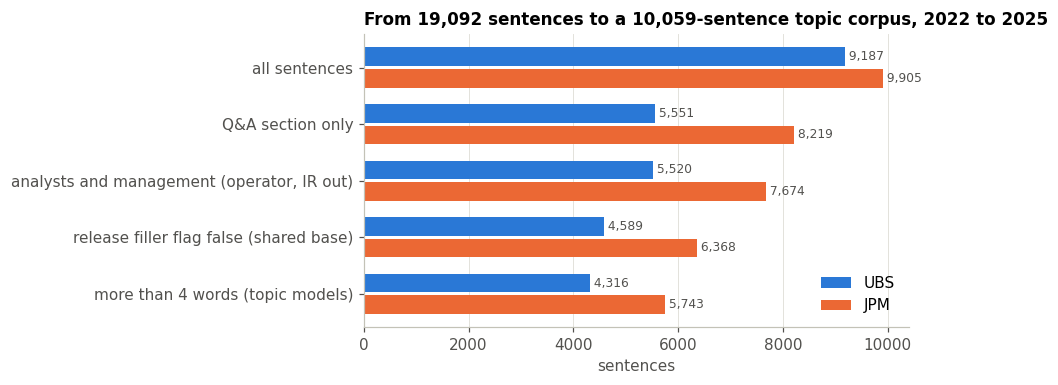

In [15]:
# 2.2 filter funnel with reasons
fig, ax = plt.subplots(figsize=(8.5, 3.6))
y, h = np.arange(len(funnel)), 0.38
for i, b in enumerate(BANKS):
    ys = y + (i - 0.5) * h
    ax.barh(ys, funnel[b], height=h - 0.05, color=BANK_COLOR[b], label=b)
    for yy, v in zip(ys, funnel[b]):
        ax.text(v, yy, f" {v:,}", va="center", fontsize=8, color="#52514e")
ax.set_yticks(y, funnel.index)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("sentences")
ax.legend(loc="lower right")
ax.set_title(f"From {funnel['total'].iloc[0]:,} sentences to a "
             f"{funnel['total'].iloc[-1]:,}-sentence topic corpus, 2022 to 2025", loc="left")
plt.tight_layout()
fig.savefig(FIG / "fig_2.2_funnel.png", dpi=150, bbox_inches="tight")
plt.show()

Charts the filtering steps for each bank, from 19,092 sentences to the 10,059-sentence topic corpus.

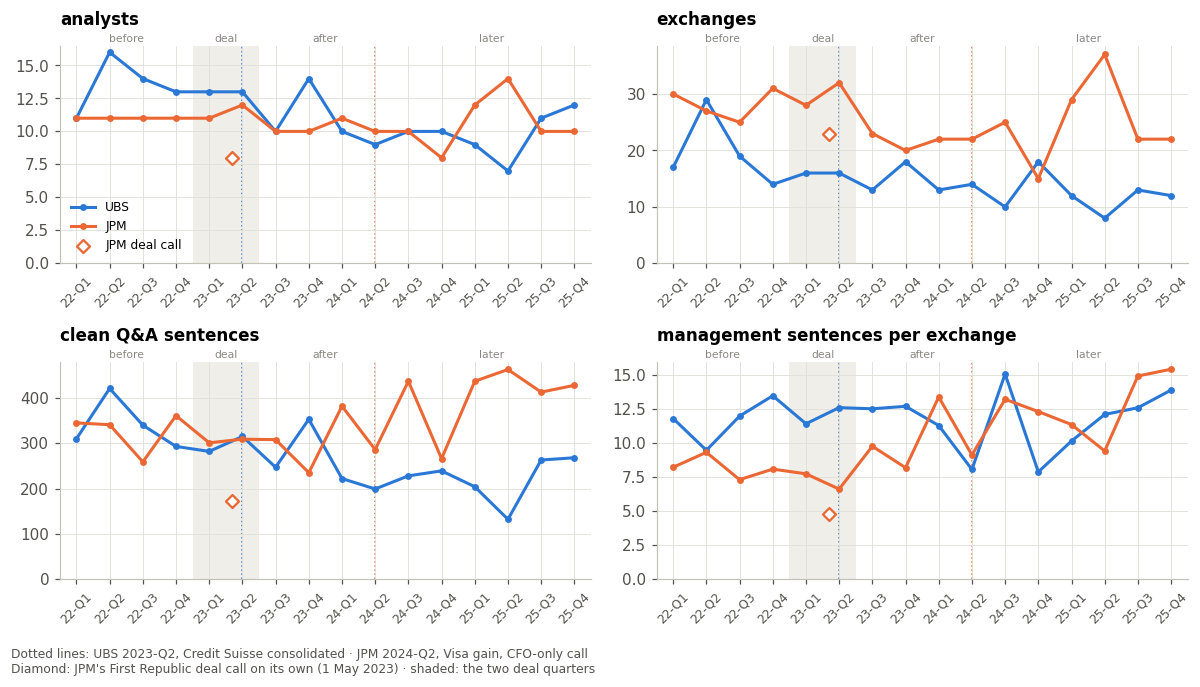

analysts  exchanges  clean Q&A sentences  \
bank call_type                                             
JPM  earnings       10.8       25.6                348.2   
     event           8.0       23.0                172.0   
UBS  earnings       11.4       15.1                269.8   

                management sentences  management sentences per exchange  
bank call_type                                                           
JPM  earnings                  256.9                               10.3  
     event                     111.0                                4.8  
UBS  earnings                  173.3                               11.7

clean Q&A sentences per year: {'JPM': {2022: 1306, 2023: 1325, 2024: 1371, 2025: 1741}, 'UBS': {2022: 1364, 2023: 1197, 2024: 888, 2025: 867}}


In [16]:
# 2.3 Q&A volume per call: analysts, exchanges with a clean analyst sentence, and how much management says
# per exchange. Lines: the earnings calls; diamond: the JPM deal call on its own.
turns = utt[utt["section"] == "qa"]
asked = qa[qa["speaker_role"] == "analyst"]
volume = pd.DataFrame({
    "analysts": turns[turns["speaker_role"] == "analyst"].groupby(CALL_ID)["speaker_name"].nunique(),
    "exchanges": asked.groupby(CALL_ID)["exchange_id"].nunique(),
    "clean Q&A sentences": qa.groupby(CALL_ID).size(),
    "management sentences": qa[qa["speaker_role"] == "management"].groupby(CALL_ID).size(),
})
volume["management sentences per exchange"] = volume["management sentences"] / volume["exchanges"]
panels = ["analysts", "exchanges", "clean Q&A sentences", "management sentences per exchange"]
fig, axes = plt.subplots(2, 2, figsize=(11, 6.2))
for ax, col in zip(axes.flat, panels):
    bank_lines(ax, volume[col].xs("earnings", level="call_type"), col)
    mark_event(ax, volume.loc[EVENT, col])
    ax.set_ylim(bottom=0)
axes[0, 0].legend(loc="lower left", fontsize=8)
fig.text(0.01, 0.005, BREAK_NOTE + "\n" + EVENT_NOTE + " · shaded: the two deal quarters",
         fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(FIG / "fig_2.3_qa_volume.png", dpi=150, bbox_inches="tight")
plt.show()
display(volume.groupby(["bank", "call_type"]).mean().round(1))
print("clean Q&A sentences per year:", qa.groupby(["bank", "year"]).size().unstack().to_dict("index"))

Q&A volume per call: both banks take questions from 7 to 16 analysts. UBS has fewer exchanges than JPMorgan (15 against 26 per call on average) and, from 2024, fewer clean sentences, down to 132 in 2025-Q2, while JPMorgan's volume grows in 2025.

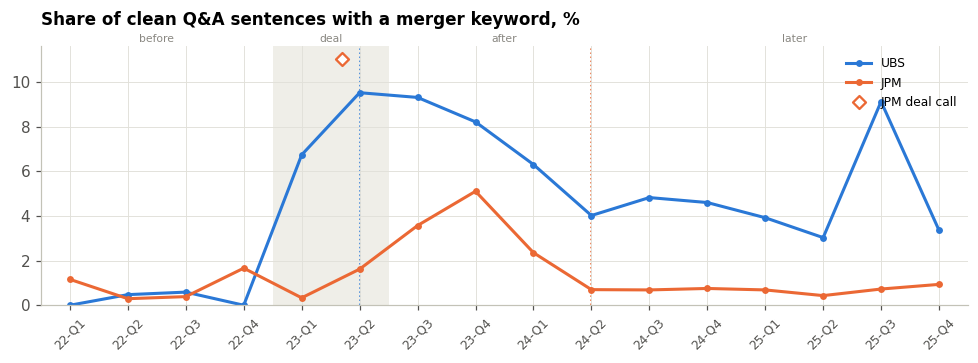

year,2022,2023,2024,2025,share_% all years
bank,,,,,
JPM,12,48,16,12,1.5
UBS,4,101,44,45,4.5


2022 hits, UBS:
    And I know that Wealthfront is not yet integrated within UBS, but maybe just a quick qualitative comment on how Wealthfront is doing in such a volatile environment regard
    So, it's not for us to update you on how they are doing, so – but I can tell you that, you know, we have prepared everything for this acquisition to be executed, and we'r
    Can you just confirm that and how you going on about your bidding out the US offering without the Wealthfront acquisition.
    And on the other side, it shows the flexibility of our investment bank in terms of the allocation of resources to move quickly from a market that is more micro related to


In [17]:
# 2.4 keyword baseline for merger talk, per quarter. Before 2023 a hit can be another deal (an acquisition
# that was planned or done elsewhere), so this is a rough count, not a measure of the merger.
MERGER_KW = re.compile(r"(?i:credit suisse|first republic|\bintegrat\w*|\bacquisi\w*|\bmerger\w*)|\bCS\b|\bFRC\b")
qa["merger_keyword"] = qa["text"].str.contains(MERGER_KW)
kw_share = 100 * qa[qa["call_type"] == "earnings"].groupby(["bank", "quarter"])["merger_keyword"].mean()
fig, ax = plt.subplots(figsize=(9, 3.4))
bank_lines(ax, kw_share, "Share of clean Q&A sentences with a merger keyword, %")
mark_event(ax, 100 * qa.loc[qa["call_type"] == "event", "merger_keyword"].mean())
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
fig.savefig(FIG / "fig_2.4_merger_keywords.png", dpi=150, bbox_inches="tight")
plt.show()
kw = qa.pivot_table(index="bank", columns="year", values="merger_keyword", aggfunc="sum")
kw["share_% all years"] = 100 * qa.groupby("bank")["merger_keyword"].mean()
display(kw.round(1))
print("2022 hits, UBS:")
for s in qa.loc[(qa["bank"] == "UBS") & (qa["year"] == 2022) & qa["merger_keyword"], "text"]:
    print("   ", s[:170])

A simple keyword search for merger talk ("Credit Suisse", "First Republic", "integration", "acquisition", "merger"). At UBS it jumps from 4 sentences in 2022 to 101 in 2023 and stays at 44 to 45 a year after; at JPMorgan it peaks at 48 in 2023. The 2022 hits at UBS are about a different deal, the planned purchase of Wealthfront. This rough count is the baseline that the topic model and the theme tagger are checked against.

In [18]:
# 2.5 answer length: words per management answer and clean sentences per answer, by bank and year
answers = utt[(utt["section"] == "qa") & (utt["speaker_role"] == "management")].copy()
answers["words"] = answers["text"].str.split().str.len()
length = answers.groupby(["bank", "year"]).agg(answers=("words", "size"), median_words=("words", "median"))
length["clean_sentences_per_answer"] = (qa[qa["speaker_role"] == "management"].groupby(["bank", "year", "turn_id"])
                                        .size().groupby(["bank", "year"]).mean())
display(length.unstack("bank").round(1))

answers      median_words        clean_sentences_per_answer     
bank     JPM  UBS          JPM    UBS                        JPM  UBS
year                                                                 
2022     203  133         53.0  117.0                        5.7  7.3
2023     214   86         73.5  189.5                        5.7  9.0
2024     152   83        104.0  151.0                        9.7  7.0
2025     265   60         38.0  244.5                        6.7  9.6

Answer length: UBS management answers are long and get longer (median 117 words in 2022, 245 in 2025), while JPMorgan's are shorter (38 to 104 words). Each management answer gives 6 to 10 clean sentences, so working at sentence level keeps long answers from being cut off at the models' input limit.

### Summary

All 33 calls are in the corpus. The two banks run their Q&A differently. JPMorgan has more exchanges per call (26 against 15) and its Q&A grows to 2025, while UBS's shrinks from 1,364 clean sentences in 2022 to 867 in 2025 and its management answers get longer (median 117 to 245 words). Analysts give about a third of UBS's sentences and about a quarter of JPMorgan's. Keyword search finds merger talk mostly at UBS: 4 sentences in 2022, 101 in 2023, then 44 or 45 a year; JPMorgan peaks at 48 in 2023.

From here on the banks are compared on shares, not counts, because their Q&A volumes move in opposite directions.

## Topics with BERTopic

BERTopic groups sentences that mean similar things and names each group by its most typical words. Nobody tells it which subjects exist, so it shows the agenda as the calls set it. It has three steps: each sentence becomes a vector (MiniLM, the smaller Sentence-BERT model); UMAP squeezes the vectors into five dimensions; HDBSCAN finds dense groups, and sentences that fit no group stay unassigned. One model is fitted on both banks and all 16 quarters, so a topic means the same thing for UBS and JPMorgan in every quarter.

**Tuning.** The setting that matters most is HDBSCAN's minimum cluster size, the smallest group that counts as a topic. The plan tried 15, 25 and 40 sentences; the first run found 68 to 159 topics at those sizes, too many to name, chart or compare in a report, so the grid now also covers 60, 80, 100 and 150. Each setting is fitted three times with different UMAP seeds, and the agreement between the runs (adjusted Rand index on the sentences both runs assign) shows whether the topics are a property of the data or of one random start. The A2 refit (76 topics, 35% unassigned) used a minimum of 15.

**Rule for the final setting:** among the settings that give 20 to 40 topics (few enough to name and compare, enough to keep the subjects apart), the one whose topics agree most across seeds; if two are within 0.02 of each other, the one that leaves fewer sentences unassigned. The first version of the rule had no topic range and picked a minimum of 15 (159 topics); the range was added after that run. The table in 3.3 keeps every setting, so the choice can be checked.

**Merger-related topics, rule fixed before the run:** a topic is merger-related when the share of its sentences with a merger keyword (2.4) is at least four times the corpus rate and at least 10 of its sentences have one.

In [19]:
# 3.1 sentence embeddings, cached next to the row keys they belong to: two pre-trained Sentence-BERT models,
# and the mpnet fine-tuned on the 56 theme examples in angelo.ipynb (not retrained here)
from sentence_transformers import SentenceTransformer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS = {"MiniLM": "sentence-transformers/all-MiniLM-L6-v2",
          "mpnet": "sentence-transformers/all-mpnet-base-v2"}
FINETUNED = A2_OUT / "sbert_themes_mpnet"
if not (FINETUNED / "model.safetensors").exists():
    raise FileNotFoundError(f"run angelo.ipynb first: it saves the fine-tuned theme model to {FINETUNED}")
SOURCES = {**MODELS, "mpnet_finetuned": str(FINETUNED)}

def free_gpu():
    # a SentenceTransformer holds a reference to itself, so `del` alone leaves its weights on the GPU
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

def encode(model, texts, batch_size=64):
    return model.encode([str(t) for t in texts], batch_size=batch_size, normalize_embeddings=True,
                        convert_to_numpy=True, show_progress_bar=False)

def embed(tag, texts, keys, batch_size=64):
    path, key_path = OUT / f"emb_qa_{tag}.npy", OUT / f"emb_qa_{tag}_keys.csv"
    if path.exists() and key_path.exists() and pd.read_csv(key_path)["key"].tolist() == list(keys):
        print(f"{tag}: loaded from {path.name}")
        return np.load(path)
    model = SentenceTransformer(SOURCES[tag], device=DEVICE)
    t0 = time.time()
    E = encode(model, texts, batch_size)
    print(f"{tag}: {E.shape[0]:,} x {E.shape[1]} in {time.time() - t0:.0f}s on {DEVICE}, "
          f"max_seq_length {model.max_seq_length}")
    np.save(path, E)
    pd.Series(list(keys), name="key").to_csv(key_path, index=False)
    del model
    free_gpu()
    return E

emb = {tag: embed(tag, qa["text"], qa["key"], batch_size=64 if tag == "MiniLM" else 32) for tag in SOURCES}
for tag, E in emb.items():
    norms = np.linalg.norm(E, axis=1)
    print(f"{tag:16s} {E.shape[0]:,} x {E.shape[1]}   norms {norms.min():.3f} to {norms.max():.3f}")

C:\local_CAM\Emp_Proj\boe-financial-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MiniLM: loaded from emb_qa_MiniLM.npy
mpnet: loaded from emb_qa_mpnet.npy
mpnet_finetuned: loaded from emb_qa_mpnet_finetuned.npy
MiniLM           10,059 x 384   norms 1.000 to 1.000
mpnet            10,059 x 768   norms 1.000 to 1.000
mpnet_finetuned  10,059 x 768   norms 1.000 to 1.000


Turns each of the 10,059 sentences into a vector three times: with the pre-trained MiniLM (384 numbers per sentence) and mpnet (768), and with the mpnet fine-tuned on the theme examples in the Assignment 2 notebook. Sentences with similar meaning get similar vectors. This took about two minutes on the laptop GPU; later runs load the saved vectors.

In [20]:
# 3.2 stop list for the topic labels only (CountVectorizer), never applied to the text the models read
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

name_tokens = {t for n in utt_raw["speaker_name"].dropna().unique() for t in re.findall(r"[a-z]{2,}", n.lower())}
other_names = {  # short forms, and executives named in the Q&A who never speak
    "steve", "ben", "nick", "andy", "charlie", "ralph", "colm", "kelleher", "iqbal", "khan",
    "marianne", "jen", "jennifer", "doug", "mary", "daniel", "pinto", "sergio", "todd", "jamie", "jeremy"}
filler_words = {  # contraction fragments and spoken fillers, plus time words
    "ve", "ll", "re", "don", "didn", "doesn", "isn", "wasn", "aren", "won", "wouldn", "couldn", "haven", "hasn",
    "just", "thank", "thanks", "okay", "ok", "right", "good", "great", "morning", "yeah", "yes", "sure",
    "know", "think", "maybe", "wanted", "guess", "really", "actually", "obviously", "look", "mean",
    "kind", "sort", "bit", "little", "lot", "going", "terms", "thing", "things", "way", "say", "said",
    "got", "like", "want", "talk", "talked", "talking", "question", "questions", "helpful", "color", "colour",
    "quarter", "quarters", "year", "years", "today",
    # BERTopic strips apostrophes before counting words, so contractions arrive as one word
    "thats", "dont", "im", "ill", "id", "youre", "theyre", "weve", "whats", "doesnt", "didnt", "isnt", "wasnt",
    "shouldnt", "wont", "cant", "ive", "youve", "lets", "theres", "hes", "wouldnt", "couldnt", "arent", "havent",
    "hasnt", "et", "cetera", "guys"}
other_names |= {"mikael"}
NAMES = name_tokens | other_names
NAMES |= {n + "s" for n in NAMES}                                   # possessives: "Jamie's" arrives as "jamies"
STOP_WORDS = sorted(ENGLISH_STOP_WORDS | NAMES | filler_words)
pd.Series(STOP_WORDS, name="token").to_csv(OUT / "stoplist_topic_labels.csv", index=False)
print(f"{len(STOP_WORDS)} stop words: {len(ENGLISH_STOP_WORDS)} English, {len(name_tokens)} speaker-name tokens, "
      f"{len(other_names)} other names, {len(filler_words)} fillers")

623 stop words: 318 English, 91 speaker-name tokens, 22 other names, 93 fillers


Builds the list of words left out of the topic labels: 488 common English words, speaker names and spoken fillers. The list only affects how topics are named; the models still read every word.

UMAP for 3 seeds in 27s


7 settings x 3 seeds clustered in 6s


,topics,"topics, other seeds",unassigned %,"unassigned %, other seeds",largest topic %,diversity,name words in top-10,agreement across seeds (ARI)
min_cluster_size,,,,,,,,
15,159,149 / 159,31.21,30 / 33,2.85,0.68,0,0.94
25,96,106 / 98,30.42,31 / 32,4.17,0.75,0,0.89
40,68,68 / 67,32.71,30 / 32,4.17,0.79,0,0.88
60,36,43 / 41,31.58,35 / 27,14.75,0.83,0,0.82
80,31,31 / 32,32.82,34 / 31,14.75,0.86,0,0.93
100,25,28 / 22,36.48,33 / 37,14.75,0.87,0,0.95
150,17,17 / 15,40.51,39 / 37,17.53,0.88,0,0.93


chosen minimum cluster size: 100


,unit,data,topics,unassigned %
run,,,,
"pilot, 20 Sep",utterance,2023 to 2024,67,not recorded
first team iteration,utterance,2023 to 2024,"12 analyst, ~20 management",11 / 14
"A2 refit, 25 Sep (minimum 15)",sentence,2023 to 2024,76,34.8
"A3, minimum 15",sentence,2022 to 2025,159,31.2
"A3, minimum 25",sentence,2022 to 2025,96,30.4
"A3, minimum 40",sentence,2022 to 2025,68,32.7
"A3, minimum 60",sentence,2022 to 2025,36,31.6
"A3, minimum 80",sentence,2022 to 2025,31,32.8
"A3, minimum 100 (chosen)",sentence,2022 to 2025,25,36.5


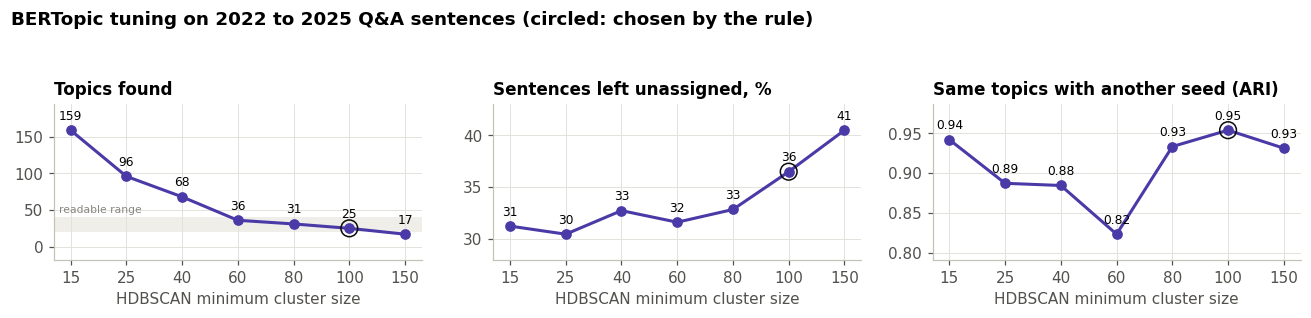

In [21]:
# 3.3 tuning: seven minimum cluster sizes, each with three UMAP seeds. UMAP runs once per seed;
# BERTopic then clusters the reduced vectors, so all settings of one seed see the same reduction.
# Seed 42 is the full BERTopic fit (topics, words); seeds 43 and 44 only check whether the groups come back.
from bertopic import BERTopic
from bertopic.dimensionality import BaseDimensionalityReduction
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import adjusted_rand_score

GRID = [15, 25, 40, 60, 80, 100, 150]
READABLE = (20, 40)          # number of topics: few enough to name and compare, enough to keep subjects apart
SEEDS = [SEED, SEED + 1, SEED + 2]
UMAP_ARGS = {"n_neighbors": 15, "n_components": 5, "min_dist": 0.0, "metric": "cosine"}
docs = qa["text"].tolist()

t0 = time.time()
reduced = {s: UMAP(random_state=s, **UMAP_ARGS).fit_transform(emb["MiniLM"]) for s in SEEDS}
print(f"UMAP for {len(SEEDS)} seeds in {time.time() - t0:.0f}s")

def clusterer(m):
    return HDBSCAN(min_cluster_size=m, min_samples=5, metric="euclidean", cluster_selection_method="eom",
                   prediction_data=True)

def fit_bertopic(m, seed=SEED):
    model = BERTopic(umap_model=BaseDimensionalityReduction(), hdbscan_model=clusterer(m),
                     vectorizer_model=CountVectorizer(stop_words=STOP_WORDS, ngram_range=(1, 2), min_df=5),
                     top_n_words=10, calculate_probabilities=False)
    topics, _ = model.fit_transform(docs, embeddings=reduced[seed])
    return model, np.asarray(topics)

def topic_words(model, n=10):
    return {t: [w for w, _ in model.get_topic(t)][:n] for t in sorted(set(model.topics_)) if t != -1}

def agreement(a, b):
    # adjusted Rand index on the sentences both runs assign to a topic
    ok = (a != -1) & (b != -1)
    return adjusted_rand_score(a[ok], b[ok])

fits, tuning = {}, []
t0 = time.time()
for m in GRID:
    fits[m] = fit_bertopic(m)
    labels = {SEED: fits[m][1], **{s: clusterer(m).fit_predict(reduced[s]) for s in SEEDS[1:]}}
    words = topic_words(fits[m][0])
    sizes = pd.Series(labels[SEED][labels[SEED] != -1]).value_counts()
    tuning.append({
        "min_cluster_size": m, "topics": len(words),
        "topics, other seeds": " / ".join(str(len(set(labels[s]) - {-1})) for s in SEEDS[1:]),
        "unassigned %": 100 * (labels[SEED] == -1).mean(),
        "unassigned %, other seeds": " / ".join(f"{100 * (labels[s] == -1).mean():.0f}" for s in SEEDS[1:]),
        "largest topic %": 100 * sizes.max() / len(docs),
        "diversity": len({w for ws in words.values() for w in ws}) / (10 * len(words)),
        "name words in top-10": sum(any(p in NAMES for p in w.split()) for ws in words.values() for w in ws),
        "agreement across seeds (ARI)": np.mean([agreement(labels[SEED], labels[s]) for s in SEEDS[1:]]),
    })
print(f"{len(GRID)} settings x {len(SEEDS)} seeds clustered in {time.time() - t0:.0f}s")
tuning = pd.DataFrame(tuning).set_index("min_cluster_size")

ok = tuning[tuning["topics"].between(*READABLE)]
ari = ok["agreement across seeds (ARI)"]
MIN_TOPIC = ok.loc[ari >= ari.max() - 0.02, "unassigned %"].idxmin()
display(tuning.round(2))
print(f"chosen minimum cluster size: {MIN_TOPIC}")

runs = pd.DataFrame([
    {"run": "pilot, 20 Sep", "unit": "utterance", "data": "2023 to 2024", "topics": "67", "unassigned %": "not recorded"},
    {"run": "first team iteration", "unit": "utterance", "data": "2023 to 2024", "topics": "12 analyst, ~20 management",
     "unassigned %": "11 / 14"},
    {"run": "A2 refit, 25 Sep (minimum 15)", "unit": "sentence", "data": "2023 to 2024", "topics": "76",
     "unassigned %": "34.8"},
] + [{"run": f"A3, minimum {m}" + (" (chosen)" if m == MIN_TOPIC else ""), "unit": "sentence", "data": "2022 to 2025",
      "topics": str(r["topics"]), "unassigned %": f"{r['unassigned %']:.1f}"} for m, r in tuning.iterrows()]).set_index("run")
display(runs)
tuning.round(3).to_csv(OUT / "topic_tuning.csv")
runs.to_csv(OUT / "topic_runs.csv")

fig, axes = plt.subplots(1, 3, figsize=(12, 2.9))
gx = np.arange(len(GRID))
axes[0].axhspan(*READABLE, color="#efeee8", lw=0, zorder=0)
axes[0].text(-0.2, READABLE[1] + 4, "readable range", ha="left", va="bottom", fontsize=7, color="#898781")
for ax, col, title in zip(axes, ["topics", "unassigned %", "agreement across seeds (ARI)"],
                          ["Topics found", "Sentences left unassigned, %", "Same topics with another seed (ARI)"]):
    ax.plot(gx, tuning[col], color="#4a3aa7", marker="o")
    ax.scatter([GRID.index(MIN_TOPIC)], [tuning.loc[MIN_TOPIC, col]], s=120, facecolors="none", edgecolors="#0b0b0b",
               zorder=3)
    for i, m in enumerate(GRID):
        ax.annotate(f"{tuning.loc[m, col]:.2f}" if col.startswith("agree") else f"{tuning.loc[m, col]:.0f}",
                    (i, tuning.loc[m, col]), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8)
    ax.set_xticks(gx, GRID)
    ax.set_xlabel("HDBSCAN minimum cluster size")
    ax.set_title(title, loc="left")
    ax.margins(y=0.25)
fig.suptitle("BERTopic tuning on 2022 to 2025 Q&A sentences (circled: chosen by the rule)", x=0.01, ha="left",
             fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(FIG / "fig_3.3_topic_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

Tries seven minimum topic sizes, each with three random starts. Small settings find many narrow topics (159 at a minimum of 15) and large ones fewer topics with more sentences left unassigned (41% at 150). Most settings give nearly the same topics from another random start (agreement 0.88 to 0.95, 0.82 at 60). Among the settings with 20 to 40 topics, a minimum of 100 is the most stable, so the model has 25 topics and leaves 36% of sentences unassigned. No speaker name reaches any topic's top ten words.

In [22]:
# 3.4 the final model and its topics: size, share of each bank's sentences, analyst share, merger keywords,
# top words. A topic is merger-related by the rule fixed above; merger-related topics are starred in the charts.
topic_model, topics = fits[MIN_TOPIC]
qa["topic"] = topics
words = topic_words(topic_model)
counts = pd.crosstab(qa["topic"], qa["bank"])
share_bank = 100 * counts / counts.sum()
MERGER_RATE = qa["merger_keyword"].mean()
kw = qa.groupby("topic")["merger_keyword"].agg(["mean", "sum"]).drop(index=-1)
MERGER_TOPICS = kw.index[(kw["mean"] >= 4 * MERGER_RATE) & (kw["sum"] >= 10)].tolist()
topic_table = pd.DataFrame({
    "sentences": counts.sum(axis=1),
    "UBS %": share_bank["UBS"], "JPM %": share_bank["JPM"],
    "analyst %": 100 * pd.crosstab(qa["topic"], qa["speaker_role"], normalize="index")["analyst"],
    "merger keyword %": 100 * qa.groupby("topic")["merger_keyword"].mean(),
    "top words": pd.Series({t: ", ".join(ws[:7]) for t, ws in words.items()}),
}).drop(index=-1).sort_values("sentences", ascending=False)
print(f"{len(topic_table)} topics; unassigned {100 * (qa['topic'] == -1).mean():.1f}% of sentences; corpus "
      f"merger-keyword rate {100 * MERGER_RATE:.1f}%; merger-related topics: {MERGER_TOPICS}")
display(topic_table.round(1))

25 topics; unassigned 36.5% of sentences; corpus merger-keyword rate 2.8%; merger-related topics: [9]


,sentences,UBS %,JPM %,analyst %,merger keyword %,top words
0,1484,12.0,16.8,21.1,0.1,"let, answer, second, time, couple, doing, happen"
1,409,5.7,2.8,33.0,1.5,"billion, cost, million, expenses, ratio, expense, costincome"
2,380,4.2,3.5,44.7,3.2,"nii, gwm, net income, income, headwinds, guidance, net"
3,317,1.1,4.7,36.0,2.5,"lending, loan, loan growth, card, loans, growth, mortgages"
4,305,2.6,3.3,36.7,1.6,"deposit, deposits, migration, beta, mix, consumer, rate"
5,287,2.2,3.3,33.4,2.1,"capital, excess, excess capital, deploy, requirements, capital requirements, return"
6,263,1.5,3.5,30.0,1.5,"banking, banks, bank, investment, investment banking, investment bank, regional"
7,259,1.5,3.4,28.6,0.0,"rates, curve, rate, fed, cuts, yield, yield curve"
8,230,4.1,0.9,37.8,2.6,"net new, asia, new, net, assets, new money, fee"
9,221,5.0,0.1,28.5,44.8,"credit suisse, suisse, swiss, switzerland, credit, ubs, at1"


The 25 topics with their size, how much of each bank's Q&A they take, how much comes from analysts, and their top words. The largest topic (1,484 sentences) is conversation and procedure: sentences such as "So, that's how we think about it." that carry no subject. One topic is merger-related by the rule: Credit Suisse and Switzerland, where 45% of the sentences contain a merger keyword.

In [23]:
# 3.5 for naming: the five sentences nearest each topic's centre (MiniLM vectors).
# Prints transcript text: clear outputs before committing.
E = emb["MiniLM"]
topic_arr = qa["topic"].to_numpy()
for t in topic_table.index:
    idx = np.flatnonzero(topic_arr == t)
    nearest = idx[np.argsort(-(E[idx] @ E[idx].mean(axis=0)))[:5]]
    print(f"\ntopic {t} · {len(idx)} sentences · {', '.join(words[t][:6])}")
    for i in nearest:
        print(f"   {qa.at[i, 'bank']} {qa.at[i, 'quarter']} {qa.at[i, 'speaker_role'][:4]}  {qa.at[i, 'text'][:160]}")


topic 0 · 1484 sentences · let, answer, second, time, couple, doing
   JPM 2025-Q3 mana  So, that's how we think about it.
   JPM 2022-Q4 mana  So we just want to be clear about that.
   JPM 2025-Q3 anal  And a two-part question for you.
   JPM 2022-Q4 mana  So, we just want to say that.
   UBS 2025-Q2 mana  Well, first of all, I think that, as I mentioned before, we're going to see exactly how things play out.

topic 1 · 409 sentences · billion, cost, million, expenses, ratio, expense
   UBS 2025-Q3 mana  So we have 3 billion that we expect to convert a significant part to net saves over the course of 2026 and drive to our underlying cost-income ratio target by t
   UBS 2022-Q3 mana  So, we mentioned, for example, that we're executing this billion-dollar growth expense save that we are on track for the $400 million that we had planned for th
   UBS 2023-Q2 mana  In terms of the cost saves in the – in terms of what we're projecting by the end of the year at 3 billion.
   UBS 2023-Q2 m

Shows the five sentences closest to the centre of each topic. Reading them is how the topics were named in the next cell.

In [24]:
# 3.6 topic names, given after reading the top words and the sentences above (3.4, 3.5). A topic without a
# name here is shown by its top three words.
TOPIC_NAMES = {
    0: "conversation and procedure", 1: "costs and cost saves", 2: "NII and revenue guidance",
    3: "loans and loan growth", 4: "deposits and deposit pricing", 5: "excess capital and its use",
    6: "banks and the banking industry", 7: "interest rates and the yield curve", 8: "net new assets and Asia",
    9: "Credit Suisse and Switzerland", 10: "outlook and timing", 11: "quarterly results and seasonality",
    12: "RWA, CET1 and returns", 13: "wealth management", 14: "buybacks and dividends",
    15: "investment spending", 16: "markets, trading and volatility", 17: "clients and client service",
    18: "risk and caution", 19: "courtesies", 20: "recession and unemployment scenarios",
    21: "return targets and percentages", 22: "credit quality and private credit",
    23: "growth ambitions and headcount", 24: "numbers and calculations",
}

def topic_label(t):
    if t == -1:
        return "unassigned"
    return f"{t} {TOPIC_NAMES[t]}" if t in TOPIC_NAMES else f"{t}: " + ", ".join(words[t][:3])

topic_table.insert(0, "name", [topic_label(t) for t in topic_table.index])
qa["topic_label"] = qa["topic"].map(topic_label)
topic_table.insert(len(topic_table.columns) - 1, "merger-related", topic_table.index.isin(MERGER_TOPICS))
topic_table.round(2).to_csv(OUT / "topic_info.csv")
qa[["key", "sentence_id", "topic", "topic_label"]].to_csv(OUT / "topics_sentence.csv", index=False)
print(f"named {len(TOPIC_NAMES)} of {len(topic_table)} topics; wrote topic_info.csv and topics_sentence.csv")

named 25 of 25 topics; wrote topic_info.csv and topics_sentence.csv


Gives each topic a short name, chosen by reading its words and sentences, and saves the topic of every sentence with its key, so it can be joined with other models' results.

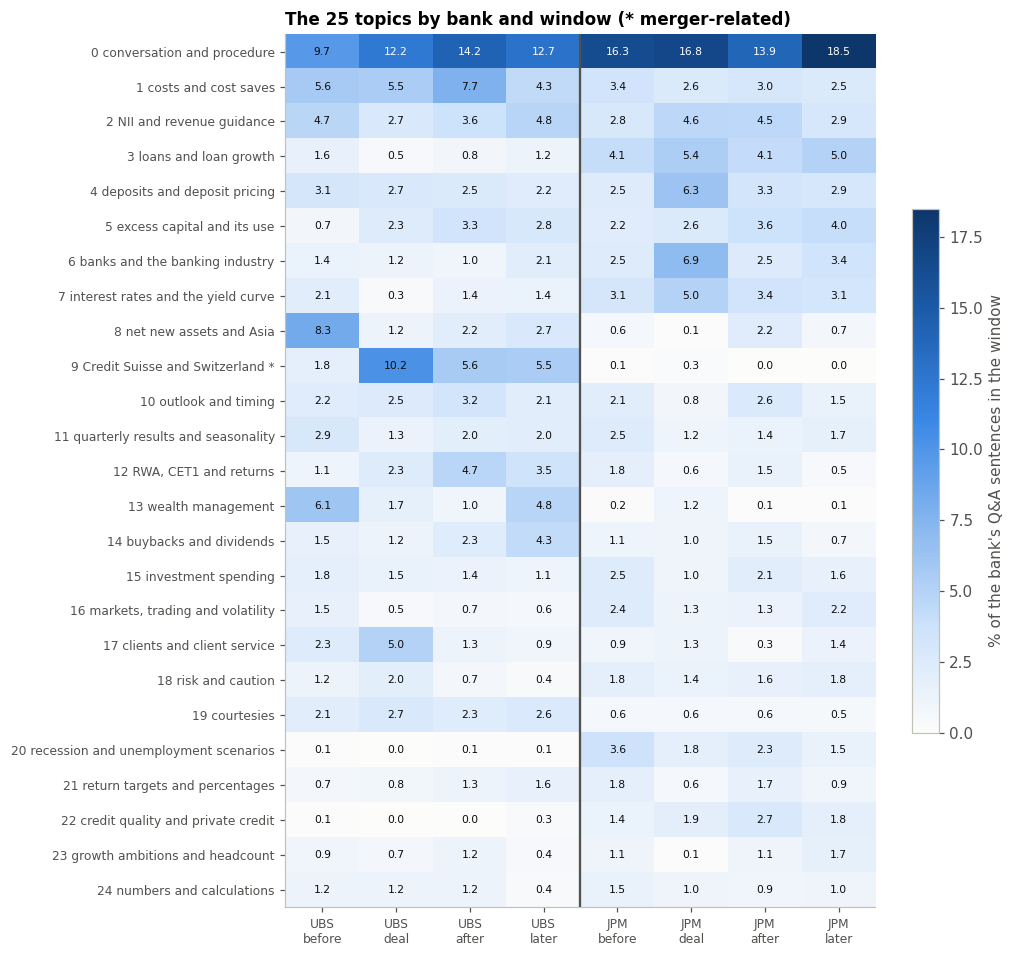

changes from before (2022) to after (2023-Q3 to 2024-Q2) whose 95% interval excludes zero, largest first


,bank,topic,before %,after %,change,lo,hi,clear
9,UBS,8 net new assets and Asia,8.3,2.2,-6.1,-8.3,-4.1,True
14,UBS,13 wealth management,6.1,1.0,-5.1,-7.6,-2.8,True
1,UBS,0 conversation and procedure,9.7,14.2,4.5,1.5,7.5,True
10,UBS,9 Credit Suisse and Switzerland,1.8,5.6,3.7,2.0,5.6,True
13,UBS,"12 RWA, CET1 and returns",1.1,4.7,3.6,1.7,5.5,True
6,UBS,5 excess capital and its use,0.7,3.3,2.6,1.2,4.0,True


,bank,topic,before %,after %,change,lo,hi,clear
35,JPM,8 net new assets and Asia,0.6,2.2,1.6,0.2,3.1,True


In [25]:
# 3.7 topic shares per bank and window, with 95% intervals from resampling whole utterances (sentences of
# one answer are not independent, so the answer is the unit that is resampled). Shares are of all the bank's
# sentences in the window, unassigned ones included, so they compare across banks and windows.
B = 1000
TOPICS = [-1] + topic_table.index.tolist()

def resample_weights(rng, n_units, n=B):
    # n bootstrap samples as counts: row i says how often each unit was drawn in sample i
    W = np.zeros((n, n_units))
    np.add.at(W, (np.arange(n)[:, None], rng.integers(0, n_units, size=(n, n_units))), 1)
    return W

def unit_counts(df, col, cats):
    return pd.crosstab(df["turn_id"], df[col]).reindex(columns=cats, fill_value=0).to_numpy()

def shares(df, col, cats, rng):
    # point shares per category, and B bootstrap replicates from resampled utterances
    counts = unit_counts(df, col, cats)
    boot = resample_weights(rng, len(counts)) @ counts
    return counts.sum(axis=0) / counts.sum(), boot / boot.sum(axis=1, keepdims=True)

rng = np.random.default_rng(SEED)
boot_w, rows = {}, []
for (b, w), g in qa.groupby(["bank", "window"]):
    point, boot = shares(g, "topic", TOPICS, rng)
    boot_w[b, w] = boot
    lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
    rows += [{"bank": b, "window": w, "topic": t, "name": topic_label(t), "share": 100 * point[k],
              "lo": 100 * lo[k], "hi": 100 * hi[k]} for k, t in enumerate(TOPICS)]
topic_win = pd.DataFrame(rows)
topic_win.round(2).to_csv(OUT / "topic_shares_bank_window.csv", index=False)

show = topic_table.index.tolist()
mat = topic_win.pivot_table(index="topic", columns=["bank", "window"], values="share").reindex(
    index=show, columns=pd.MultiIndex.from_product([BANKS, WINDOW_NAMES]))
fig, ax = plt.subplots(figsize=(9.5, 0.28 * len(show) + 1.8))
im = ax.imshow(mat.to_numpy(), aspect="auto", cmap=BLUES, vmin=0)
for (i, j), v in np.ndenumerate(mat.to_numpy()):
    ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7,
            color="white" if v > 0.6 * np.nanmax(mat.to_numpy()) else "#0b0b0b")
ax.set_xticks(range(mat.shape[1]), [f"{b}\n{w}" for b, w in mat.columns], fontsize=8)
ax.set_yticks(range(len(show)), [topic_label(t) + (" *" if t in MERGER_TOPICS else "") for t in show], fontsize=8)
ax.axvline(len(WINDOW_NAMES) - 0.5, color="#52514e", lw=1.5)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.6, label="% of the bank's Q&A sentences in the window")
ax.set_title(f"The {len(show)} topics by bank and window (* merger-related)", loc="left")
plt.tight_layout()
fig.savefig(FIG / "fig_3.7_topics_by_window.png", dpi=150, bbox_inches="tight")
plt.show()

# change from the year before the deals to the year after, with a 95% interval from the two bootstraps
moves = []
for b in BANKS:
    d = 100 * (boot_w[b, "after"] - boot_w[b, "before"])
    lo, hi = np.percentile(d, [2.5, 97.5], axis=0)
    p = topic_win[topic_win["bank"] == b].pivot(index="topic", columns="window", values="share").reindex(TOPICS)
    moves += [{"bank": b, "topic": topic_label(t), "before %": p.at[t, "before"], "after %": p.at[t, "after"],
               "change": p.at[t, "after"] - p.at[t, "before"], "lo": lo[k], "hi": hi[k]}
              for k, t in enumerate(TOPICS)]
moves = pd.DataFrame(moves)
moves["clear"] = (moves["lo"] > 0) | (moves["hi"] < 0)
moves.round(2).to_csv(OUT / "topic_change_before_after.csv", index=False)
print("changes from before (2022) to after (2023-Q3 to 2024-Q2) whose 95% interval excludes zero, largest first")
for b in BANKS:
    m = moves[(moves["bank"] == b) & moves["clear"]]
    display(m.reindex(m["change"].abs().sort_values(ascending=False).index).head(10).round(1))

Topic shares by bank and window, with 95% ranges from resampling whole answers. From the year before the deal to the year after, UBS talks much less about net new assets and Asia (8.3% to 2.2%) and wealth management (6.1% to 1.0%), and more about Credit Suisse and Switzerland (1.8% to 5.6%), capital ratios and returns (1.1% to 4.7%) and excess capital (0.7% to 3.3%). At JPMorgan only one topic moves beyond its range, net new assets (0.6% to 2.2%), so its agenda stays steady through its deal.

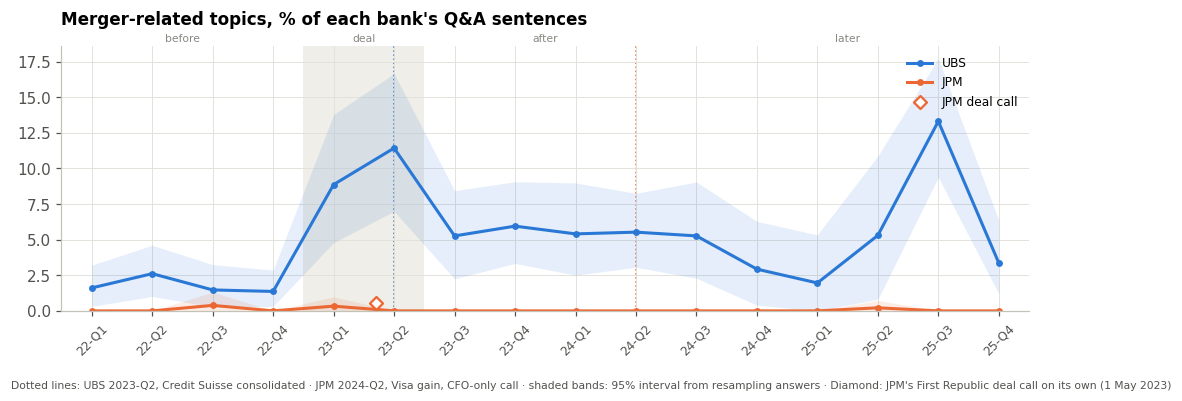

quarter,2022-Q1,2022-Q2,2022-Q3,2022-Q4,2023-Q1,2023-Q2,2023-Q3,2023-Q4,2024-Q1,2024-Q2,2024-Q3,2024-Q4,2025-Q1,2025-Q2,2025-Q3,2025-Q4
bank,,,,,,,,,,,,,,,,
JPM,0.0,0.0,0.4,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.0
UBS,1.6,2.6,1.5,1.4,8.9,11.4,5.3,5.9,5.4,5.5,5.3,2.9,2.0,5.3,13.3,3.4


JPM deal call alone: 0.6%


In [26]:
# 3.8 merger-related topics per quarter: their combined share of each bank's sentences, with 95% intervals
qa["merger_topic"] = qa["topic"].isin(MERGER_TOPICS)
rng = np.random.default_rng(SEED)
rows = []
for (b, q), g in qa[qa["call_type"] == "earnings"].groupby(["bank", "quarter"]):
    point, boot = shares(g, "merger_topic", [False, True], rng)
    lo, hi = np.percentile(boot[:, 1], [2.5, 97.5])
    rows.append({"bank": b, "quarter": q, "share": 100 * point[1], "lo": 100 * lo, "hi": 100 * hi})
merger_q = pd.DataFrame(rows).set_index(["bank", "quarter"])
deal_call = 100 * qa.loc[qa["call_type"] == "event", "merger_topic"].mean()

fig, ax = plt.subplots(figsize=(9.5, 3.6))
for b in BANKS:
    s = merger_q.xs(b, level="bank").reindex(QUARTERS)
    ax.fill_between(X, s["lo"], s["hi"], color=BANK_COLOR[b], alpha=0.12, lw=0)
    ax.plot(X, s["share"], color=BANK_COLOR[b], marker="o", ms=3.5, label=b)
mark_event(ax, deal_call)
time_axis(ax, "Merger-related topics, % of each bank's Q&A sentences")
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", fontsize=8)
fig.text(0.01, 0.005, BREAK_NOTE + " · shaded bands: 95% interval from resampling answers · " + EVENT_NOTE,
         fontsize=7, color="#52514e")
plt.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(FIG / "fig_3.8_merger_topics.png", dpi=150, bbox_inches="tight")
plt.show()
merger_q.round(2).to_csv(OUT / "merger_topics_bank_quarter.csv")
display(merger_q["share"].unstack("quarter").reindex(columns=QUARTERS).round(1))
print(f"JPM deal call alone: {deal_call:.1f}%")

The merger-related topic over time. At UBS it rises from about 2% in 2022 to 11% in the closing quarter (2023-Q2), stays at about 5% for a year and a half, and peaks again at 13% in 2025-Q3, when the Q&A turns to the appeal over the Credit Suisse AT1 bonds, legacy legal cases and the new Swiss capital rules. JPMorgan has no merger topic: its First Republic talk is too small for a topic of at least 100 sentences, so the theme tagger in the next section is the better measure there.

### Summary

BERTopic was fitted once on the 10,059 clean Q&A sentences of both banks, 2022 to 2025, with MiniLM vectors. Seven minimum topic sizes were tried, each with three random starts. The topics are stable at most sizes (agreement 0.88 to 0.95), and the most stable setting with 20 to 40 topics (a minimum of 100 sentences) gives 25 topics and leaves 36% of sentences unassigned. The first version of the rule had no topic range and picked 159 topics; the range was added after that run, because 159 topics cannot be read or compared in a report. One topic is procedural (15% of sentences) and one is merger-related: Credit Suisse and Switzerland.

The topics show how UBS's agenda changed through the deal. From 2022 to the year after, net new assets in Asia and wealth management fall from 14% of its Q&A to 3%, while Credit Suisse, capital ratios and excess capital rise from 4% to 14%. The Credit Suisse topic peaks in the closing quarter (11%) and again in 2025-Q3 (13%), with the AT1 appeal, legacy cases and the Swiss capital rules, so the merger is still on the agenda two years after closing. JPMorgan's agenda hardly moves (one topic beyond its range), and its First Republic talk is too small to form a topic of its own.

This separates the merger from the sector: subjects both banks share, such as rates, deposits and capital, move together, while the topics only UBS has trace the takeover and how long it lasts.

## Themes with the fine-tuned Sentence-BERT tagger

The second model reads the same sentences against seven fixed themes (integration, restructuring, capital, risk, costs, revenue, other). Each sentence takes the theme whose eight example sentences it is closest to. The tagger is the mpnet model fine-tuned on those 56 examples in `angelo.ipynb`, where it placed 50 of 56 held-out examples correctly against 43 before fine-tuning. It depends only on the examples, so it is reused unchanged here; only the sentences it tags are new.

Where BERTopic lets the data set the subjects, the tagger asks a fixed question of every quarter, so its shares can be tracked over time and compared with the A2 results. Comparing the two (4.4) is the topic track's check between models.

In [27]:
# 4.1 tag every sentence: the fine-tuned mpnet (main), and the two pre-trained models as checks.
# Same codebook and examples as angelo.ipynb.
from sklearn.metrics import cohen_kappa_score

EXAMPLES = {
    "integration": [
        "The integration of the acquired bank is progressing well and we remain on track with our milestones.",
        "We are migrating the acquired clients and accounts onto our own platforms and systems.",
        "The merger of the two legal entities was completed after the transaction closed.",
        "Purchase accounting, negative goodwill and other acquisition-related effects from the deal.",
        "How is the combination of the two businesses going, and what are the remaining integration risks?",
        "When will the legal entities be merged, and when will the acquired clients be on one platform?",
        "How much of the integration work is still ahead of you, and what are the next milestones?",
        "Most clients of the acquired bank have stayed with us since the takeover.",
    ],
    "restructuring": [
        "We continue to wind down the legacy portfolio and exit businesses that do not fit our strategy.",
        "Running off non-core positions released risk-weighted assets and reduced the balance sheet.",
        "The reorganisation involves closing overlapping units and simplifying the group structure.",
        "Restructuring charges and exit costs were higher this quarter.",
        "How much longer will it take to wind down the remaining legacy book?",
        "We agreed to sell a business that is no longer core to the group.",
        "The run-down of the non-core unit is ahead of plan, with fewer positions left to exit.",
        "We are reorganising our divisions into a simpler structure with fewer layers of management.",
    ],
    "capital": [
        "Our CET1 capital ratio remains well above the regulatory requirement.",
        "We intend to return excess capital to shareholders through share buybacks and dividends.",
        "The proposed capital rules and Basel III requirements would increase the capital we need to hold.",
        "Liquidity and funding remain strong, with a comfortable liquidity coverage ratio.",
        "Risk-weighted assets and the leverage ratio determine how much balance sheet we can deploy.",
        "When do you expect to restart share buybacks, and at what size?",
        "How do you think about the payout split between dividends and buybacks over the next few years?",
        "The capital surcharge and the stress capital buffer set how much capital we must hold.",
    ],
    "risk": [
        "Credit quality remains solid, but we expect net charge-offs to normalise from low levels.",
        "We added to our loan loss reserves because the macroeconomic outlook weakened.",
        "Exposure to commercial real estate and office loans is an area we are watching closely.",
        "Litigation, legal provisions and regulatory investigations remain a risk to earnings.",
        "Market volatility and geopolitical uncertainty could affect the portfolio.",
        "Rates staying higher for longer could strain borrowers and slow the economy.",
        "Card net charge-offs rose as consumer credit continued to normalise.",
        "Higher rates have caused unrealised losses in the securities portfolio.",
    ],
    "costs": [
        "We are on track to deliver the planned gross cost savings.",
        "Expenses rose this quarter, driven by investment in technology and higher compensation.",
        "Our cost-to-income ratio should improve as the efficiency measures come through.",
        "We reduced headcount and contractor spend to bring the cost base down.",
        "What is your expense guidance for next year?",
        "We expect adjusted expenses for next year to be roughly in line with this year.",
        "Compensation costs went up because of higher performance-related pay.",
        "Technology, marketing and real estate were the main drivers of the increase in non-compensation expenses.",
    ],
    "revenue": [
        "Net interest income will come down as deposit costs rise and balances move to higher-yielding products.",
        "Investment banking fees and markets revenue were strong compared with last year.",
        "Wealth management attracted net new assets and fee income grew.",
        "Our outlook assumes modest loan growth and a few rate cuts next year.",
        "Client activity and consumer spending remain healthy.",
        "Net interest income guidance for next year depends on the path of rate cuts and the forward curve.",
        "We are winning back market share and client flows are returning.",
        "What is your outlook for revenue growth and returns over the next few years?",
    ],
    "other": [
        "Thank you, that is very helpful.",
        "Let me take your second question.",
        "I would just add one point to that.",
        "What exactly do you mean by that?",
        "We are not going to comment on speculation.",
        "That is a fair question, and we will come back to it.",
        "We will give you more detail on that at a later date.",
        "I think that is broadly right, and we will see how it plays out.",
    ],
}
THEMES = list(EXAMPLES)
assert all(len(v) == 8 for v in EXAMPLES.values()), "eight examples per theme"
ex_text = np.array([s for v in EXAMPLES.values() for s in v])
ex_label = np.array([t for t, v in EXAMPLES.items() for _ in v])

def centroids(E_ex, labels):
    C = np.vstack([E_ex[labels == t].mean(axis=0) for t in THEMES])
    return C / np.linalg.norm(C, axis=1, keepdims=True)

def tag_themes(E, C):
    # nearest theme centroid, and the margin over the runner-up (how clear-cut the choice is)
    S = E @ C.T
    top2 = np.sort(S, axis=1)[:, -2:]
    return np.array(THEMES)[S.argmax(axis=1)], top2[:, 1] - top2[:, 0]

for tag in SOURCES:
    model = SentenceTransformer(SOURCES[tag], device=DEVICE)
    C = centroids(encode(model, ex_text), ex_label)
    del model
    free_gpu()
    qa[f"theme_{tag}"], qa[f"margin_{tag}"] = tag_themes(emb[tag], C)
qa["theme"] = qa["theme_mpnet_finetuned"]

tag_checks = pd.DataFrame({tag: {
    "merger sentences tagged integration %": 100 * (qa.loc[qa["merger_keyword"], f"theme_{tag}"] == "integration").mean(),
    "same theme as the fine-tuned mpnet %": 100 * (qa[f"theme_{tag}"] == qa["theme"]).mean(),
    "other %": 100 * (qa[f"theme_{tag}"] == "other").mean(),
    "median margin": qa[f"margin_{tag}"].median()} for tag in SOURCES}).T
display(tag_checks.round(1))
print(f"pre-trained MiniLM against the fine-tuned mpnet: kappa "
      f"{cohen_kappa_score(qa['theme_MiniLM'], qa['theme']):.2f}")

# reproducibility: the same sentences in the A2 run (23 September release, 2023 and 2024) should get the same theme
a2 = pd.read_csv(A2_OUT / "themes_sentence.csv")[["key", "theme"]].rename(columns={"theme": "theme_A2"})
a2_text = pd.read_parquet(A2_OUT / "qa_sentences.parquet")[["key", "text"]].rename(columns={"text": "text_A2"})
both = qa.merge(a2, on="key").merge(a2_text, on="key")
same_text = both["text"] == both["text_A2"]
print(f"sentences in both runs: {len(both):,}; same text {100 * same_text.mean():.1f}%; same theme "
      f"{100 * (both['theme'] == both['theme_A2']).mean():.1f}% (same text only: "
      f"{100 * (both.loc[same_text, 'theme'] == both.loc[same_text, 'theme_A2']).mean():.1f}%)")
qa[["key", "sentence_id", "theme", "margin_mpnet_finetuned", "theme_MiniLM", "theme_mpnet"]].to_csv(
    OUT / "themes_sentence.csv", index=False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8168.92it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11190.81it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10333.61it/s]

,merger sentences tagged integration %,same theme as the fine-tuned mpnet %,other %,median margin
MiniLM,34.4,63.3,33.6,0.1
mpnet,36.9,74.1,36.3,0.1
mpnet_finetuned,48.2,100.0,37.8,0.2


pre-trained MiniLM against the fine-tuned mpnet: kappa 0.53
sentences in both runs: 4,675; same text 99.4%; same theme 99.6% (same text only: 100.0%)


Tags every sentence with one of the seven themes, using the fine-tuned mpnet and, as checks, the two pre-trained models. Fine-tuning still sends more merger-keyword sentences to integration (48% against 34% and 37% before fine-tuning), and about 38% of sentences fit no theme and land in "other". The tagger is reproducible: on the 4,675 sentences that are also in the Assignment 2 run, it gives the same theme to every sentence whose text is unchanged.

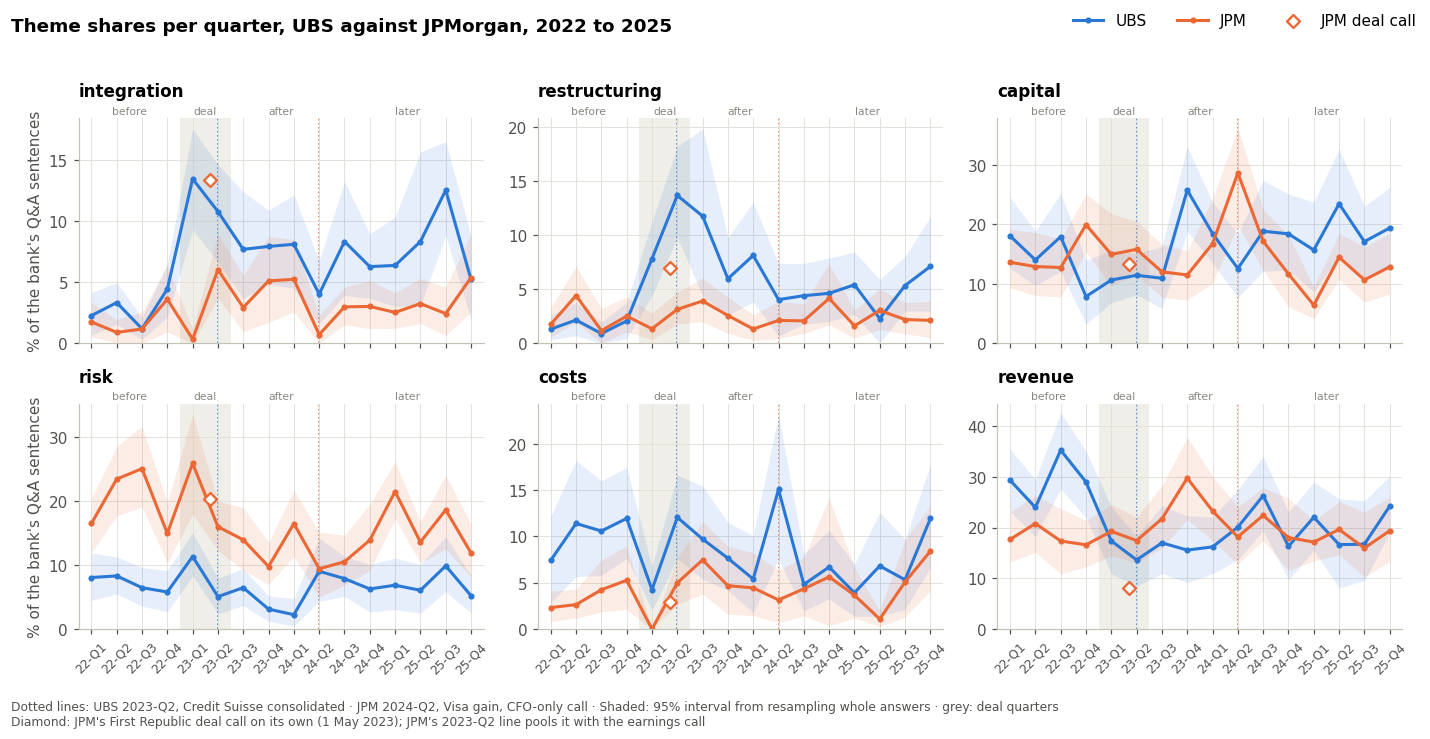

theme share by bank and window (% of sentences)


UBS                      JPM                  
              before  deal after later before  deal after later
theme                                                          
integration      2.8  12.1   7.1   7.9    1.9   3.8   3.6   3.3
restructuring    1.6  10.9   7.4   5.1    2.5   2.4   2.4   2.4
capital         14.6  11.1  18.0  18.5   15.0  15.5  17.3  12.3
risk             7.3   8.0   4.9   7.1   19.6  19.8  12.9  15.1
costs           10.4   8.4   9.1   6.7    3.6   3.1   5.0   4.6
revenue         29.1  15.4  16.9  20.6   18.1  18.2  23.0  18.9
other           34.2  34.2  36.4  34.0   39.2  37.2  35.9  43.5

In [28]:
# 4.2 theme shares per bank and quarter (fine-tuned tagger), with 95% intervals from resampling utterances.
# JPM 2023-Q2 pools the earnings call and the deal call; the diamond shows the deal call alone.
rng = np.random.default_rng(SEED)
records = []
for (b, q), g in qa.groupby(["bank", "quarter"]):
    point, boot = shares(g, "theme", THEMES, rng)
    lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
    records += [{"bank": b, "quarter": q, "theme": t, "share": 100 * point[k], "lo": 100 * lo[k],
                 "hi": 100 * hi[k]} for k, t in enumerate(THEMES)]
prevalence = pd.DataFrame(records)
prevalence.round(2).to_csv(OUT / "theme_shares_bank_quarter.csv", index=False)
deal_themes = pd.Series(100 * shares(qa[qa["call_type"] == "event"], "theme", THEMES, rng)[0], index=THEMES)

fig, axes = plt.subplots(2, 3, figsize=(13, 6.6), sharex=True)
for ax, t in zip(axes.flat, [t for t in THEMES if t != "other"]):
    p = prevalence[prevalence["theme"] == t].set_index(["bank", "quarter"])
    for b in BANKS:
        s = p.xs(b, level="bank").reindex(QUARTERS)
        ax.fill_between(X, s["lo"], s["hi"], color=BANK_COLOR[b], alpha=0.12, lw=0)
        ax.plot(X, s["share"], color=BANK_COLOR[b], marker="o", ms=3, label=b)
    mark_event(ax, deal_themes[t])
    time_axis(ax, t)
    ax.set_ylim(bottom=0)
for ax in axes[:, 0]:
    ax.set_ylabel("% of the bank's Q&A sentences")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper right", ncol=3)
fig.suptitle("Theme shares per quarter, UBS against JPMorgan, 2022 to 2025", x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, BREAK_NOTE + " · Shaded: 95% interval from resampling whole answers · grey: deal quarters\n"
         + EVENT_NOTE + "; JPM's 2023-Q2 line pools it with the earnings call", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.05, 1, 0.96))
fig.savefig(FIG / "fig_4.2_theme_shares.png", dpi=150, bbox_inches="tight")
plt.show()

print("theme share by bank and window (% of sentences)")
display(qa.pivot_table(index="theme", columns=["bank", "window"], values="key", aggfunc="count")
        .div(qa.groupby(["bank", "window"]).size(), axis=1).mul(100).round(1)
        .reindex(index=THEMES, columns=pd.MultiIndex.from_product([BANKS, WINDOW_NAMES])).fillna(0))

Theme shares per quarter with 95% ranges. In 2022 UBS talks little about integration and restructuring (2.8% and 1.6%); in the two deal quarters these jump to 12.1% and 10.9%, and they stay well above JPMorgan's in every later window. UBS's revenue share falls from 29% in 2022 to 15% to 21%, while JPMorgan talks more about risk throughout (13% to 20% against 5% to 8% at UBS). JPMorgan's deal call is its most merger-focused call (about 13% integration).

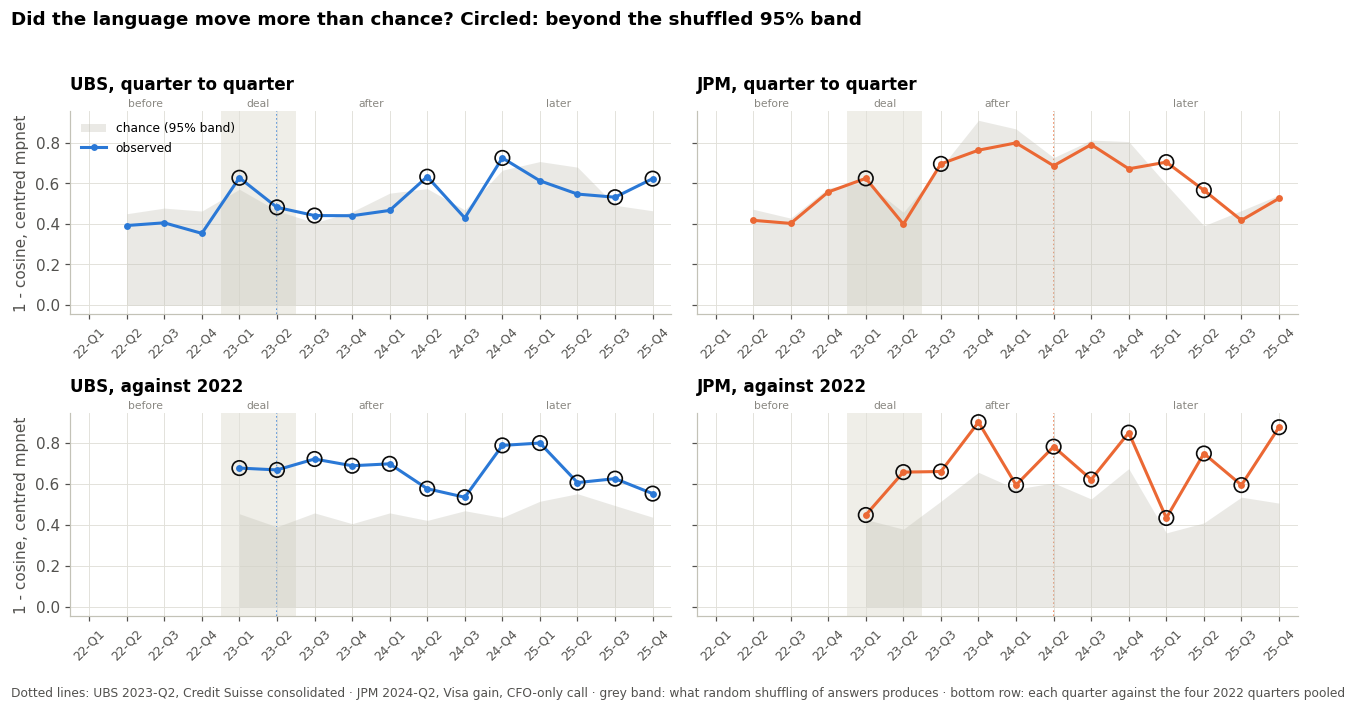

steps beyond chance, out of those tested


variant                  mpnet, pre-trained MiniLM, pre-trained  \
bank measure                                                      
UBS  quarter to quarter             7 of 15             8 of 15   
     against 2022                  12 of 12            12 of 12   
     window against 2022             3 of 3              3 of 3   
JPM  quarter to quarter             4 of 15             4 of 15   
     against 2022                  12 of 12            11 of 12   
     window against 2022             3 of 3              3 of 3   

variant                  mpnet, fine-tuned  \
bank measure                                 
UBS  quarter to quarter            7 of 15   
     against 2022                 12 of 12   
     window against 2022            3 of 3   
JPM  quarter to quarter            5 of 15   
     against 2022                  9 of 12   
     window against 2022            3 of 3   

variant                  mpnet, pre-trained, earnings calls only  
bank measure                                                      
UBS  quarter to quarter                                  7 of 15  
     against 2022                                       12 of 12  
     window against 2022                                  3 of 3  
JPM  quarter to quarter                                  5 of 15  
     against 2022                                       11 of 12  
     window against 2022                                  3 of 3

correlation of the excess over chance with the main run: {'MiniLM, pre-trained': np.float64(0.92), 'mpnet, fine-tuned': np.float64(0.85), 'mpnet, pre-trained, earnings calls only': np.float64(0.96)}
each window against 2022 (main run): distance, chance level and excess


observed  chance  chance 95%  excess  beyond chance
bank period                                                     
UBS  deal      0.6235  0.2069      0.3150  0.4165           True
     after     0.5899  0.1574      0.2296  0.4324           True
     later     0.4940  0.1421      0.2057  0.3520           True
JPM  deal      0.5034  0.1992      0.2828  0.3042           True
     after     0.5785  0.2518      0.3646  0.3267           True
     later     0.5443  0.1573      0.2273  0.3870           True

In [29]:
# 4.3 semantic drift, tested against chance. Embeddings are centred on the pooled mean, so the banking vocabulary
# both banks share cancels out, then averaged per group. Distance = 1 - cosine between two group centroids, and
# every distance is compared with the same measure after shuffling whole utterances between the two groups
# (500 times): only a value above the shuffled 95% band is a real change.
# Three questions: quarter to quarter; each quarter against 2022 (the year before the deals); and each window
# against 2022. The main run uses the pre-trained mpnet on purpose: drift should catch any change in language,
# not only change along the seven themes. Checks: the other model, the fine-tuned vectors, earnings calls only.
N_SHUFFLE = 500
VARIANTS = {"mpnet, pre-trained": ("mpnet", qa.index),
            "MiniLM, pre-trained": ("MiniLM", qa.index),
            "mpnet, fine-tuned": ("mpnet_finetuned", qa.index),
            "mpnet, pre-trained, earnings calls only": ("mpnet", qa.index[qa["call_type"] == "earnings"])}
MAIN = next(iter(VARIANTS))

def unit(X):
    return X / np.linalg.norm(X, axis=-1, keepdims=True)

def utterance_sums(E, g):
    codes, units = pd.factorize(g["turn_id"])
    sums = np.zeros((len(units), E.shape[1]))
    np.add.at(sums, codes, E[g.index.to_numpy()])
    return sums, np.bincount(codes)

def distance_vs_chance(sums_a, n_a, sums_b, n_b, rng):
    # 1 - cosine between the two groups' centroids, and the same after shuffling utterances between the groups
    observed = 1 - unit(sums_a.sum(0) / n_a.sum()) @ unit(sums_b.sum(0) / n_b.sum())
    S, n = np.vstack([sums_a, sums_b]), np.concatenate([n_a, n_b])
    in_a = np.zeros((N_SHUFFLE, len(n)))
    for i in range(N_SHUFFLE):
        in_a[i, rng.permutation(len(n))[:len(n_a)]] = 1
    ca, cb = unit((in_a @ S) / (in_a @ n)[:, None]), unit(((1 - in_a) @ S) / ((1 - in_a) @ n)[:, None])
    null = 1 - (ca * cb).sum(axis=1)
    return observed, null.mean(), np.percentile(null, 97.5)

rng = np.random.default_rng(SEED)
drift_rows = []
for name, (tag, rows_used) in VARIANTS.items():
    used = qa.loc[rows_used]
    E = emb[tag] - emb[tag][used.index].mean(axis=0)
    parts = {(b, q): utterance_sums(E, g) for (b, q), g in used.groupby(["bank", "quarter"])}
    windows = {(b, w): utterance_sums(E, g) for (b, w), g in used.groupby(["bank", "window"])}
    for b in BANKS:
        for i, q in enumerate(QUARTERS):
            tests = {"against 2022": windows[b, "before"]} if q not in WINDOWS["before"] else {}
            if i > 0:
                tests["quarter to quarter"] = parts[b, QUARTERS[i - 1]]
            for measure, ref in tests.items():
                obs, chance, band = distance_vs_chance(*ref, *parts[b, q], rng)
                drift_rows.append({"variant": name, "bank": b, "measure": measure, "period": q,
                                   "observed": obs, "chance": chance, "chance 95%": band})
        for w in WINDOW_NAMES[1:]:
            obs, chance, band = distance_vs_chance(*windows[b, "before"], *windows[b, w], rng)
            drift_rows.append({"variant": name, "bank": b, "measure": "window against 2022", "period": w,
                               "observed": obs, "chance": chance, "chance 95%": band})
drift = pd.DataFrame(drift_rows)
drift["beyond chance"] = drift["observed"] > drift["chance 95%"]
drift["excess"] = drift["observed"] - drift["chance"]
drift.round(4).to_csv(OUT / "drift_bank_quarter.csv", index=False)

d = drift[drift["variant"] == MAIN]
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharey="row")
for col, b in enumerate(BANKS):
    for row, measure in enumerate(["quarter to quarter", "against 2022"]):
        ax = axes[row, col]
        s = d[(d["bank"] == b) & (d["measure"] == measure)].set_index("period").reindex(QUARTERS)
        ax.fill_between(X, 0, s["chance 95%"], color="#c3c2b7", alpha=0.35, lw=0, label="chance (95% band)")
        ax.plot(X, s["observed"], color=BANK_COLOR[b], marker="o", ms=3.5, label="observed")
        hits = s["beyond chance"].eq(True).to_numpy()
        ax.scatter(X[hits], s["observed"].to_numpy()[hits], s=90, facecolors="none", edgecolors="#0b0b0b",
                   lw=1.1, zorder=3)
        time_axis(ax, f"{b}, {measure}", [b])
axes[0, 0].set_ylabel("1 - cosine, centred mpnet")
axes[1, 0].set_ylabel("1 - cosine, centred mpnet")
axes[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Did the language move more than chance? Circled: beyond the shuffled 95% band",
             x=0.01, ha="left", fontweight="bold")
fig.text(0.01, 0.005, BREAK_NOTE + " · grey band: what random shuffling of answers produces · "
         "bottom row: each quarter against the four 2022 quarters pooled", fontsize=8, color="#52514e")
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
fig.savefig(FIG / "fig_4.3_drift_vs_chance.png", dpi=150, bbox_inches="tight")
plt.show()

print("steps beyond chance, out of those tested")
display(drift.groupby(["bank", "measure", "variant"], sort=False)["beyond chance"]
        .agg(lambda s: f"{s.sum()} of {s.count()}").unstack("variant")[list(VARIANTS)])
wide = drift.pivot_table(index=["bank", "measure", "period"], columns="variant", values="excess")
print("correlation of the excess over chance with the main run:",
      {v: round(wide[MAIN].corr(wide[v]), 2) for v in VARIANTS if v != MAIN})
print("each window against 2022 (main run): distance, chance level and excess")
display(d[d["measure"] == "window against 2022"].set_index(["bank", "period"])
        [["observed", "chance", "chance 95%", "excess", "beyond chance"]].round(4))

Tests whether each bank's language moved more than chance, comparing every change with 500 random reshuffles of the answers. Quarter to quarter, UBS moved beyond chance in 7 of 15 steps and JPMorgan in 4 of 15. Against 2022, every later quarter differs beyond chance at both banks, so both talk differently than before the deals; UBS's distance is largest in the deal and after windows, JPMorgan's in the later window. The results hold with the other model, the fine-tuned vectors and the earnings calls alone (correlation 0.85 to 0.96).

adjusted mutual information, topics against themes: 0.24
sentences whose theme is their topic's main theme: 61.5%
main theme of the topics: {'integration': 1, 'restructuring': 0, 'capital': 4, 'risk': 2, 'costs': 1, 'revenue': 12, 'other': 5}
unassigned sentences by theme (%): {'integration': 6.0, 'restructuring': 5.5, 'capital': 15.5, 'risk': 12.0, 'costs': 8.3, 'revenue': 15.9, 'other': 36.7}


,name,sentences,main theme,main theme %
topic,,,,
0,0 conversation and procedure,1484,other,94.5
1,1 costs and cost saves,409,costs,41.6
2,2 NII and revenue guidance,380,revenue,48.9
3,3 loans and loan growth,317,revenue,44.8
4,4 deposits and deposit pricing,305,revenue,52.5
5,5 excess capital and its use,287,capital,77.7
6,6 banks and the banking industry,263,revenue,36.1
7,7 interest rates and the yield curve,259,revenue,48.6
8,8 net new assets and Asia,230,revenue,53.9


merger-related topics: share of their sentences the tagger calls integration (%) {'9 Credit Suisse and Switzerland': np.float64(26.7)}


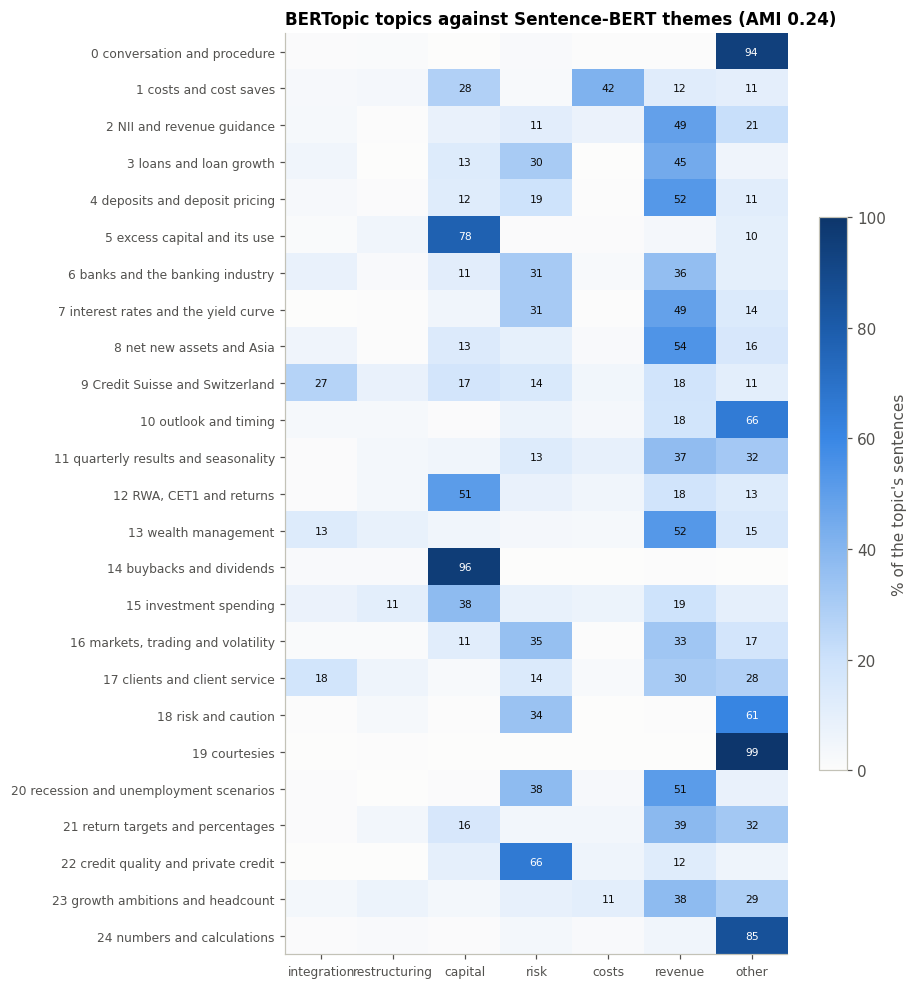

In [30]:
# 4.4 the two models side by side: which theme dominates each topic, and how strongly. Agreement is measured
# with adjusted mutual information (0 = no more than chance, 1 = the same grouping) on assigned sentences.
from sklearn.metrics import adjusted_mutual_info_score

assigned = qa[qa["topic"] != -1]
ct = pd.crosstab(assigned["topic"], assigned["theme"]).reindex(columns=THEMES, fill_value=0)
purity = ct.max(axis=1) / ct.sum(axis=1)
cross = pd.DataFrame({"name": [topic_label(t) for t in ct.index], "sentences": ct.sum(axis=1),
                      "main theme": ct.idxmax(axis=1), "main theme %": 100 * purity}).sort_values(
    "sentences", ascending=False)
ct.to_csv(OUT / "topic_theme_crosstab.csv")
ami = adjusted_mutual_info_score(assigned["topic"], assigned["theme"])
print(f"adjusted mutual information, topics against themes: {ami:.2f}")
print(f"sentences whose theme is their topic's main theme: {100 * (ct.max(axis=1).sum() / ct.to_numpy().sum()):.1f}%")
print("main theme of the topics:", cross["main theme"].value_counts().reindex(THEMES, fill_value=0).to_dict())
print("unassigned sentences by theme (%):",
      (100 * qa.loc[qa["topic"] == -1, "theme"].value_counts(normalize=True)).reindex(THEMES).round(1).to_dict())
display(cross.round(1))
print("merger-related topics: share of their sentences the tagger calls integration (%)",
      {topic_label(t): round(100 * (qa.loc[qa["topic"] == t, "theme"] == "integration").mean(), 1) for t in MERGER_TOPICS})

rown = 100 * ct.loc[show].div(ct.loc[show].sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(8.5, 0.3 * len(show) + 1.6))
im = ax.imshow(rown.to_numpy(), aspect="auto", cmap=BLUES, vmin=0, vmax=100)
for (i, j), v in np.ndenumerate(rown.to_numpy()):
    if v >= 10:
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7, color="white" if v > 60 else "#0b0b0b")
ax.set_xticks(range(len(THEMES)), THEMES, fontsize=8)
ax.set_yticks(range(len(show)), [topic_label(t) for t in show], fontsize=8)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.6, label="% of the topic's sentences")
ax.set_title(f"BERTopic topics against Sentence-BERT themes (AMI {ami:.2f})", loc="left")
plt.tight_layout()
fig.savefig(FIG / "fig_4.4_topics_vs_themes.png", dpi=150, bbox_inches="tight")
plt.show()

Compares the two models sentence by sentence. Many topics have a clear main theme: buybacks and dividends (96% capital), excess capital (78% capital) and the procedural topics (85% to 99% other). Overall 62% of topic sentences carry their topic's main theme, and the agreement score is 0.24, low but above chance (0), because the topics split business subjects more finely than the seven themes do. Only 27% of the Credit Suisse topic is tagged integration: the topic also holds Swiss business and capital talk.

### Summary

The fine-tuned Sentence-BERT tagger from Assignment 2 was reused without retraining on the 2022 to 2025 sentences, and on the sentences both runs share it gives exactly the same themes. With 2022 as the baseline, the merger shows clearly at UBS: integration and restructuring go from 2.8% and 1.6% in 2022 to 12% and 11% in the deal quarters, and two years later they are still at 5% to 8%, about three times the 2022 level. JPMorgan's integration share stays at 2% to 4%, with its deal call as the exception (about 13%). UBS's language moved beyond chance in 7 of 15 quarter-to-quarter steps against 4 of 15 at JPMorgan. At both banks every later quarter differs from 2022 beyond chance, so part of the change is the sector (rates, the 2023 bank failures), not only the merger.

The two models agree where they should (capital, procedure) and differ in grain. BERTopic finds subjects the seven themes do not name, such as net new assets in Asia or private credit; the themes catch merger talk at JPMorgan that is too small to become a topic. Together they give a fixed measure that can be tracked over time and an open view of the agenda.

## Comparison with the sentiment models

The team's sentiment analysis ran four models (FinBERT, FinBERT-tone, RoBERTa and an emotion model) on the same release and flagged six quarters where the tone changed. None of those changes was confirmed by more than two models at once. This section asks whether the language itself also moved in those quarters: does the topic mix, the theme mix or the overall meaning (drift, 4.3) change more than chance from the quarter before? The same tests run on every other quarter, so the flagged quarters can be compared with a base rate.

This compares at quarter level. Topics within negative sentences need the sentiment labels sentence by sentence, joined on the key (bank, quarter, call type, position in call, sentence number); that step is listed under Next.

In [31]:
# 5.1 quarter-to-quarter shift in the topic mix and the theme mix, tested against chance like the drift in 4.3:
# total variation distance (half the sum of absolute share differences) between two quarters, against the same
# measure after shuffling whole utterances between them 500 times. Then the six flagged quarters against the rest.
FLAGGED = {("UBS", "2022-Q4"): "FinBERT-tone, prepared remarks",
           ("UBS", "2024-Q1"): "RoBERTa, more negative Q&A",
           ("UBS", "2025-Q4"): "RoBERTa, more negative Q&A",
           ("JPM", "2024-Q3"): "RoBERTa, more negative Q&A",
           ("JPM", "2025-Q1"): "RoBERTa, more negative Q&A",
           ("JPM", "2025-Q2"): "RoBERTa, more negative Q&A"}

def mix_shift_vs_chance(counts_a, counts_b, rng):
    tvd = lambda a, b: 0.5 * np.abs(a / a.sum(-1, keepdims=True) - b / b.sum(-1, keepdims=True)).sum(-1)
    observed = tvd(counts_a.sum(0), counts_b.sum(0))
    S = np.vstack([counts_a, counts_b])
    in_a = np.zeros((N_SHUFFLE, len(S)))
    for i in range(N_SHUFFLE):
        in_a[i, rng.permutation(len(S))[:len(counts_a)]] = 1
    null = tvd(in_a @ S, (1 - in_a) @ S)
    return observed, null.mean(), np.percentile(null, 97.5)

rng = np.random.default_rng(SEED)
shift_rows = []
for b in BANKS:
    for i in range(1, len(QUARTERS)):
        prev, q = QUARTERS[i - 1], QUARTERS[i]
        ga, gb = qa[(qa["bank"] == b) & (qa["quarter"] == prev)], qa[(qa["bank"] == b) & (qa["quarter"] == q)]
        row = {"bank": b, "quarter": q, "flagged": FLAGGED.get((b, q), "")}
        for col, cats in (("topic", TOPICS), ("theme", THEMES)):
            obs, chance, band = mix_shift_vs_chance(unit_counts(ga, col, cats), unit_counts(gb, col, cats), rng)
            row[f"{col} shift"], row[f"{col} beyond chance"] = obs, obs > band
            pa, pb = (100 * g[col].value_counts(normalize=True) for g in (ga, gb))
            diff = pb.reindex(cats, fill_value=0) - pa.reindex(cats, fill_value=0)
            top_move = diff.abs().idxmax()
            row[f"largest {col} move"] = (f"{topic_label(top_move) if col == 'topic' else top_move} "
                                          f"{diff[top_move]:+.1f} pts")
        dd = drift[(drift["variant"] == MAIN) & (drift["bank"] == b) & (drift["measure"] == "quarter to quarter")
                   & (drift["period"] == q)].iloc[0]
        row["drift beyond chance"] = bool(dd["beyond chance"])
        shift_rows.append(row)
shift = pd.DataFrame(shift_rows)
shift.round(4).to_csv(OUT / "sentiment_quarters_check.csv", index=False)

print("the six quarters flagged by the sentiment models")
display(shift[shift["flagged"] != ""].set_index(["bank", "quarter"])[
    ["flagged", "drift beyond chance", "topic beyond chance", "theme beyond chance",
     "largest topic move", "largest theme move"]])
tests = ["drift beyond chance", "topic beyond chance", "theme beyond chance"]
base_rate = shift.assign(group=np.where(shift["flagged"] != "", "flagged quarters", "other quarters")) \
            .groupby("group")[tests].agg(lambda s: f"{s.sum()} of {s.count()}")
print("how often the language moved beyond chance: flagged quarters against the rest")
display(base_rate)

the six quarters flagged by the sentiment models


flagged  drift beyond chance  \
bank quarter                                                        
UBS  2022-Q4  FinBERT-tone, prepared remarks                False   
     2024-Q1      RoBERTa, more negative Q&A                False   
     2025-Q4      RoBERTa, more negative Q&A                 True   
JPM  2024-Q3      RoBERTa, more negative Q&A                False   
     2025-Q1      RoBERTa, more negative Q&A                 True   
     2025-Q2      RoBERTa, more negative Q&A                 True   

              topic beyond chance  theme beyond chance  \
bank quarter                                             
UBS  2022-Q4                False                 True   
     2024-Q1                False                False   
     2025-Q4                 True                 True   
JPM  2024-Q3                False                False   
     2025-Q1                False                False   
     2025-Q2                False                 True   

                                            largest topic move  \
bank quarter                                                     
UBS  2022-Q4                     13 wealth management +9.3 pts   
     2024-Q1                               unassigned +6.3 pts   
     2025-Q4          9 Credit Suisse and Switzerland -9.9 pts   
JPM  2024-Q3        21 return targets and percentages -3.7 pts   
     2025-Q1  20 recession and unemployment scenarios +4.7 pts   
     2025-Q2             5 excess capital and its use +4.0 pts   

             largest theme move  
bank quarter                     
UBS  2022-Q4    other +11.3 pts  
     2024-Q1     other +7.4 pts  
     2025-Q4   revenue +7.5 pts  
JPM  2024-Q3  capital -11.5 pts  
     2025-Q1      risk +7.6 pts  
     2025-Q2   capital +8.1 pts

how often the language moved beyond chance: flagged quarters against the rest


,drift beyond chance,topic beyond chance,theme beyond chance
group,,,
flagged quarters,3 of 6,1 of 6,3 of 6
other quarters,8 of 24,3 of 24,4 of 24


Checks the six quarters the sentiment models flagged. In half of them the language moved beyond chance from the quarter before (3 of 6, against 8 of the 24 other quarters), and the theme mix shifted beyond chance in 3 of 6 (4 of 24 otherwise). The topic mix moved beyond chance only in UBS 2025-Q4, when Credit Suisse talk fell by 10 points. Six quarters are too few to prove a link, but they show where tone and subject changed together: UBS 2025-Q4 and JPMorgan 2025-Q2 (more capital talk).

### Summary

The six quarters where the sentiment models saw a tone change were tested for a change in what was said. Three of the six also show a change in language beyond chance (as do 8 of the 24 other quarters), and the theme mix shifts beyond chance in three of six (4 of 24). The clearest match is UBS 2025-Q4, where language, topics and themes all move as Credit Suisse talk drops and revenue talk rises; at JPMorgan, 2025-Q1 brings more recession talk and 2025-Q2 more capital talk. Six quarters are too few for a firm conclusion, and one flag (UBS 2022-Q4) comes from the prepared remarks, which this notebook does not model.

The comparison gives the sentiment results a subject: when tone and topic change together, the topic says what the tone is about. The next step joins the sentiment labels sentence by sentence to show which topics carry the negative tone.

## Analysts against management

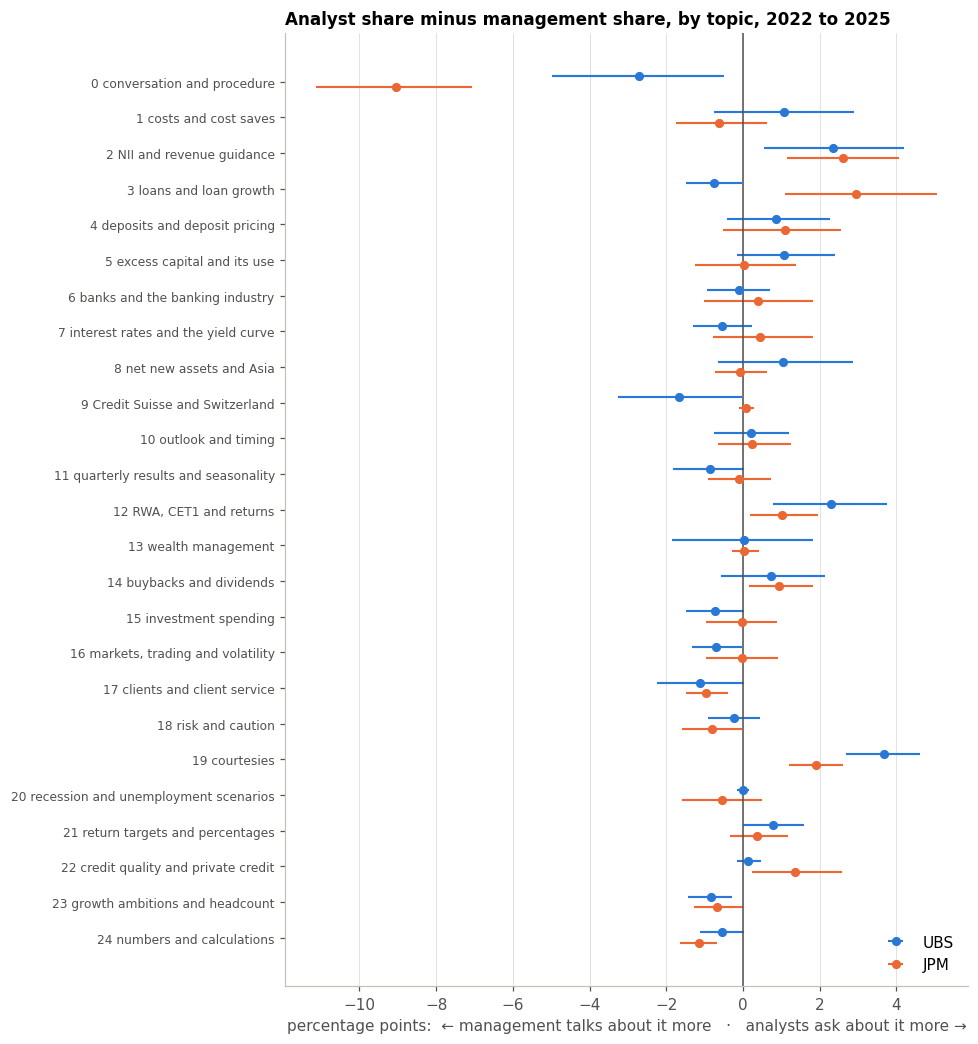

topics where the gap's 95% interval excludes zero, largest first


name  gap    lo   hi
bank topic                                                      
JPM  0              0 conversation and procedure -9.1 -11.1 -7.1
UBS  19                            19 courtesies  3.7   2.7  4.6
JPM  3                   3 loans and loan growth  3.0   1.1  5.1
UBS  0              0 conversation and procedure -2.7  -5.0 -0.5
JPM  2                2 NII and revenue guidance  2.6   1.1  4.1
UBS  2                2 NII and revenue guidance  2.3   0.6  4.2
     12                 12 RWA, CET1 and returns  2.3   0.8  3.8
JPM  19                            19 courtesies  1.9   1.2  2.6
UBS  9           9 Credit Suisse and Switzerland -1.7  -3.3 -0.0
JPM  22     22 credit quality and private credit  1.4   0.2  2.6
     24              24 numbers and calculations -1.1  -1.6 -0.7
     12                 12 RWA, CET1 and returns  1.0   0.2  2.0
     14                14 buybacks and dividends  1.0   0.2  1.8
     17            17 clients and client service -1.0  -1.5 -0.4
UBS  23        23 growth ambitions and headcount -0.8  -1.4 -0.3
JPM  18                      18 risk and caution -0.8  -1.6 -0.0

In [32]:
# 6.1 analyst share minus management share per topic, in percentage points, for each bank over 2022 to 2025.
# Positive: analysts raise the topic more than management talks about it. 95% intervals from resampling
# utterances within each role.
rng = np.random.default_rng(SEED)
gap_rows = []
for b in BANKS:
    for w in ["all"] + WINDOW_NAMES:
        g = qa[(qa["bank"] == b) & ((qa["window"] == w) | (w == "all"))]
        (pa, ba), (pm, bm) = (shares(g[g["speaker_role"] == r], "topic", TOPICS, rng) for r in ROLES)
        lo, hi = np.percentile(100 * (ba - bm), [2.5, 97.5], axis=0)
        gap_rows += [{"bank": b, "window": w, "topic": t, "name": topic_label(t), "gap": 100 * (pa[k] - pm[k]),
                      "lo": lo[k], "hi": hi[k]} for k, t in enumerate(TOPICS)]
gap = pd.DataFrame(gap_rows)
gap.round(2).to_csv(OUT / "analyst_management_topic_gap.csv", index=False)

g = gap[gap["window"] == "all"].set_index(["bank", "topic"])
fig, ax = plt.subplots(figsize=(9, 0.32 * len(show) + 1.6))
y = np.arange(len(show))
for i, b in enumerate(BANKS):
    r = g.xs(b, level="bank").reindex(show)
    yy = y + (i - 0.5) * 0.3
    ax.errorbar(r["gap"], yy, xerr=[r["gap"] - r["lo"], r["hi"] - r["gap"]], fmt="o", ms=5,
                color=BANK_COLOR[b], ecolor=BANK_COLOR[b], elinewidth=1.4, capsize=0, label=b)
ax.axvline(0, color="#52514e", lw=1)
ax.set_yticks(y, [topic_label(t) for t in show], fontsize=8)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("percentage points:  ← management talks about it more   ·   analysts ask about it more →")
ax.legend(loc="lower right")
ax.set_title("Analyst share minus management share, by topic, 2022 to 2025", loc="left")
plt.tight_layout()
fig.savefig(FIG / "fig_6.1_analyst_gap_topics.png", dpi=150, bbox_inches="tight")
plt.show()

clear = g[(g["lo"] > 0) | (g["hi"] < 0)].drop(index=-1, level="topic", errors="ignore")
print("topics where the gap's 95% interval excludes zero, largest first")
display(clear.reindex(clear["gap"].abs().sort_values(ascending=False).index)[["name", "gap", "lo", "hi"]]
        .head(16).round(1))

Compares what analysts ask about with what management talks about, by topic. At both banks analysts raise NII and revenue guidance and capital ratios more than management does (by 1 to 3 points), and at JPMorgan also loans and credit quality. Management says more that has no subject (conversation and procedure, 9 points more at JPMorgan) and, at UBS, slightly more about Credit Suisse and Switzerland than its analysts ask about it.

### Summary

Analysts at both banks push on NII guidance and capital ratios more than management raises them, and at JPMorgan also on loans and credit quality. Management fills more of its answers with procedure and framing, and at UBS speaks slightly more about Credit Suisse and Switzerland than analysts ask about it.

The analyst side shows what the market wants explained. A subject analysts keep pressing that management does not take up is worth a closer look.

## Next

- **Topics within negative sentences.** Join the sentiment group's labels sentence by sentence on the key (bank, quarter, call type, position in call, sentence number), then read the topic and theme mix of negative sentences per bank, before and after the deals, with ranges. `topics_sentence.csv` and `themes_sentence.csv` hold the key.
- **One topic model for the report.** Agree with the topics group which BERTopic setting goes into the final notebook, so the report shows one topic model and its tuning record.
- **Prepared remarks.** The tagger and the topic model can also read the prepared remarks, which would line up with the sentiment track's comparison of prepared remarks and Q&A.
- Before any commit: clear all outputs (public repository) and add only this notebook.